# Conditional Multi-Channel Training ("PNN") — 1l2tau + 2l2tau Combined, Run 2 + Run 3 (Combined)

**Terminology check first, because it changes what's allowed here.** The
original parameterized NN (Baldi, Cranmer, Faucett, Gross & Whiteson, 2016)
conditions on a **physics** parameter - canonically a resonance mass - so
that one network `f(x, θ)` stands in for many mass-specific networks, and
because θ is continuous the network *interpolates* to mass points never
trained on. The defining trick is that background has no meaningful θ, so
θ is drawn randomly from signal's distribution for background events -
otherwise the network just learns "θ has a sensible value ⟹ signal" and
collapses.

**Channel is not that kind of parameter.** It's a real, observed property
of every event - signal, background, and (eventually) data alike. An event
genuinely has one lepton or two; there's no "channel 1.5" to interpolate
to. So:
- `channel_id` is **never randomized for background** - that
  trick only applies to parameters that exist for signal and are undefined
  for background. Getting this backwards is the most common way to break
  this technique.
- There is **no interpolation** happening here.

People in ATLAS/CMS still call this a "PNN" and this notebook keeps that
name for continuity with the sibling model notebooks, but mechanically it's
**conditional multi-channel training**: one shared network sees both
channels' events with a channel indicator as an extra input, for reasons
like shared feature learning, more effective statistics for the common
physics, and one model to maintain instead of several - not for
interpolation. (If a resonant X→HH search with multiple m_X points ever
enters this analysis, that WOULD be a genuine PNN axis - randomized for
background, interpolatable - layered on top of the channel/era flags below,
which stay real and non-randomized. The code here is structured so adding
that later is a straightforward extra column, not a rewrite.)

## Encoding: single ordinal column, not one-hot

`channel_id` is a **single** ordinal 0/1 column (0 = 1l2tau, 1 = 2l2tau),
not two one-hot columns. With only two channels in scope today and no
near-term plan to add a third sub-channel (2lSS, 2lSS+1τ, 3l, ...), a
single ordinal column is simpler to train and reason about than one-hot -
the usual objection to ordinal encoding (that it implies a false distance/
ordering between categories) doesn't bite with just two categories. If a
third channel is ever added, revisit this (one-hot, or an embedding, would
then be worth the extra complexity).

**Note:** the project's `is_feature()` leakage policy blocks
`hhml_subchannelflavor` as a leakage risk. `channel_id` is, in
spirit, a reintroduction of exactly that kind of information. This is
**deliberate and intended** here (conditioning on channel is the whole
point of this notebook) - NOT a leakage bug, so please don't "fix" it by
re-blocking this column later.

## The real hard part: reconciling the feature schemas

1l2tau gives `l1`, `τ1`, `τ2`. 2l2tau gives `l1`, `l2`, `τ1`, `τ2` - so
`m_l1l2`/`dR_l1l2`/etc. exist only in 2l2tau. Taking the plain
**intersection** of leakage-free features (what `discover_common_features`
already does per-channel) silently throws away exactly the second-lepton
variables that make 2l2tau powerful. Three options, increasing effort:

1. **Intersection only** (what this notebook does). Loses real
   discriminating power, but is the right first version to prove the
   plumbing works.
2. **Union + sentinel + presence flags.** Keep every column; where a
   variable is undefined for a channel, fill a fixed out-of-range value
   plus an `is_defined` companion flag, and fit imputation/scaling
   PER CHANNEL (a global median/scaler would smear together two different
   channel-specific distributions).
3. **Generic object slots** (lep1, lep2-or-absent, tau1, tau2, ...) with
   type flags, so a column means the same thing everywhere - the natural
   on-ramp to DeepSets/particle-transformer architectures.

**Suggested order (this notebook = step 1):** intersection features +
channel indicator + per-cell weights, evaluated per channel against the solo
baselines. If that holds, move to union features with presence flags.
Worry about conditioning depth (input-concat vs. per-layer vs. FiLM) last.

## Weighting: per-cell, not global

A global `make_fit_weights` balances signal vs. background over the WHOLE
pooled sample. Pool two channels (or eras) with very different event
counts and the loss gets dominated by whichever cell has the most MC
events - and, more subtly, the network ends up learning
`p(signal | x, channel)` INCLUDING the prior `p(signal | channel)` implied
by the weights, so its output baseline silently shifts per channel (a cut
at 0.9 would mean something different in each channel). This notebook
balances signal vs. background WITHIN each `(channel × run × class)` cell
first, then mean-normalizes globally - see `make_fit_weights(...,
cell_ids=...)` below. Run2 and Run3 have different MC statistics per
process too, so now that both are combined the same cell-weighting logic
is applied jointly across `channel` and `run`, not just `channel`.

## Evaluation: pooled AUC will lie

If one channel is intrinsically cleaner, pooling raises the headline AUC
even if the model got WORSE in the other channel. This notebook always
reports **per-channel** AUC/Z first, and the "Comparison Against
Solo-Channel Baselines" section near the end checks the only comparison
that actually matters: does the combined model beat each channel's OWN
solo-trained models (XGBoost/MLP/DNN/GNN) IN THAT CHANNEL. AUC also isn't
the endpoint - HH is at S/B ≈ 1.3×10⁻⁴ preselection-level, so the real
figure of merit is expected significance from a binned fit in the high-score
tail, reported here via the Asimov-Z scan (per channel too).

## Scope of this pass

Run 2 **and** Run 3, combined per channel first (`load_combined_run` -
own `discover_common_features`/`load_run_data`/`clean_data` per run, then
intersected on features with a `run` tag, mirroring the Run2+Run3
"Combined" track used by `DNN.ipynb`/`GNN_Evie.ipynb`), and THEN the two
channels' Combined samples are combined on top of that, exactly as before.
Every stratification/weighting step that already existed for `channel`
(train/val/test split strata, per-cell signal/background balancing) is now
extended to `channel` × `run` jointly, since Run2 and Run3 have different
MC statistics per process - the same imbalance risk the "Weighting"
section above already warns about for channels, now doubled for runs.

**Correlation pruning / top-15 stage:** now included (see "Correlation
Pruning & Retraining" below), mirroring the XGBoost master pipeline and the
solo MLP/DNN/GNN notebooks' full → pruned (top-20) → top-15 ladder, so the
"Comparison Against Solo-Channel Baselines" section compares this
notebook's final model against each solo model's own final (top-15) model
on the same footing. The one exception: `channel_id` is
**excluded from the importance-ranking/pruning candidate pool** and
**unconditionally re-appended** to every pruned/top-15 feature set - it
is the entire point of this notebook, not a redundant physics input, so a
generic correlation-pruning walk must never be allowed to drop it just
because it didn't rank in the top 30 by permutation importance.



## Libraries

In [1]:
import os

# Must be set BEFORE CUDA/cuBLAS initializes for deterministic cuBLAS matmul.
# If this kernel already has CUDA initialized (e.g. you've run cells before
# adding this), these two env vars won't take effect until you RESTART THE
# KERNEL.

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import json
import pickle
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import uproot
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

RANDOM_STATE = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = RANDOM_STATE):

    """
    Full determinism, not just seeding: also pins cuDNN to deterministic
    kernels, disables its autotuner, and asks torch to error out (rather than
    silently fall back) on any op without a deterministic implementation.
    Determinism is only guaranteed on the SAME machine / CUDA / torch
    version - it is not portable across hardware or library versions.
    """

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)


set_seed(RANDOM_STATE)

print(f"Using device: {DEVICE}")


Using device: cuda


In [2]:
# ---------------------------------------------------------------------------
# Paths - BOTH channels, Run 2 AND Run 3 (each channel is combined into its
# own Run2+Run3 "Combined" sample first - see "Load Both Channels" below -
# and THEN the two channels are combined into one PNN training sample; see
# intro markdown). Each channel keeps its own base dirs/preselection/
# leakage-blocklist - they are only combined AFTER independent
# discover/load/clean, in the "PNN Parameter: Channel" section below.
# ---------------------------------------------------------------------------

BASE_DIR_1L2TAU_RUN2 = Path("PPSSP_2026/1l2tau/run2")
BASE_DIR_1L2TAU_RUN3 = Path("PPSSP_2026/1l2tau/run3")

BASE_DIR_2L2TAU_RUN2 = Path("PPSSP_2026/2l2tau/run2")
BASE_DIR_2L2TAU_RUN3 = Path("PPSSP_2026/2l2tau/run3")
TREE_NAME = "AnalysisMiniTree"

# ---------------------------------------------------------------------------
# Preselections (see repo README.md) - differ per channel.
# ---------------------------------------------------------------------------

PRESELECTION_1L2TAU = "(n_b_jet == 0) & (n_jet >= 2)"
PRESELECTION_2L2TAU = "(n_b_jet == 0) & (l1_charge * l2_charge < 0) & (mZ_cut > 0)"

# ---------------------------------------------------------------------------
# Processes: filename + label (1 = signal, 0 = background) - same file names
# in both channels' directories.
# ---------------------------------------------------------------------------

FILES = {
    "signal_ggF": ("signal_ggF.root", 1),
    "signal_VBF": ("signal_VBF.root", 1),
    "Diboson":    ("diboson.root",    0),
    "Zjets":      ("Zjets.root",      0),
    "Wjets":      ("Wjets.root",      0),
    "ttbar":      ("ttbar.root",      0),
    "tops":       ("tops.root",       0),
    "SingleH":    ("singleH.root",    0),
    "Vgamma":     ("Vgamma.root",     0),
    "VVV":        ("VVV.root",        0),
}

WEIGHT_PARTS = ["weight", "weights"]  # raw branches; w_phys = their product
EVENT_ID_BRANCH = "eventNumber"        # bookkeeping only - NEVER a feature (see BLOCK_SUBSTR)

# ---------------------------------------------------------------------------
# Leakage-free feature-selection policy - BLOCK_SUBSTR is shared, but
# BLOCK_EXACT differs per channel (each has its own preselection-flag/
# pair-flag branch names, and 2l2tau has extra always-constant-post-cut
# branches). Identical to 1L2Tau_Master_Pipeline.ipynb /
# 2L2Tau_Master_Pipeline.ipynb.
# ---------------------------------------------------------------------------

BLOCK_SUBSTR = ["weight", "effsf", "_ff", "truth", "istrue", "fake", "anti",
                "dsid", "eventnumber", "_RNNTight", "_isOS", "_d0sig"]

BLOCK_EXACT_1L2TAU = {
    "n_b_jet", "pass1l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSleptau", "tau2_baseline_RNNTight", "l1_d0sig",
    "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode",
    "tau1_nprong", "tau2_nprong",
}

BLOCK_EXACT_2L2TAU = {
    "n_b_jet", "pass2l2tau", "hhml_subchannelflavor",
    "tau1_RNNJetScoreSigTrans", "tau2_RNNJetScoreSigTrans",
    "pair_isOStaus", "pair_isOSlep1lep2", "tau2_baseline_RNNTight", "l1_d0sig",
    "tau1_charge", "tau2_charge", "mZ_veto", "tau1_decayMode", "tau2_decayMode",
    "tau1_nprong", "tau2_nprong", "mZ_cut", "mZreq", "low_mass_cut", "xgb_score",
}


def make_is_feature(block_exact):

    """Returns an `is_feature(branch)` predicate closed over `block_exact`
    (each channel has its own exact-match blocklist; BLOCK_SUBSTR is shared)."""

    block_exact_lower = {b.lower() for b in block_exact}

    def is_feature(branch):
        lb = branch.lower()
        return lb not in block_exact_lower and not any(s.lower() in lb for s in BLOCK_SUBSTR)

    return is_feature


IS_FEATURE_1L2TAU = make_is_feature(BLOCK_EXACT_1L2TAU)
IS_FEATURE_2L2TAU = make_is_feature(BLOCK_EXACT_2L2TAU)


# ---------------------------------------------------------------------------
# K-fold knobs - shared with every other notebook in this project (see
# assign_folds in the K-Fold helper library below). N_OPTUNA_INNER_FOLDS is
# smaller than N_FOLDS deliberately: NN training is far more expensive
# per-fold than XGBoost's, so the Optuna search itself uses fewer folds than
# the final OOF rotation (which always uses the full N_FOLDS) - an
# efficiency tradeoff, not a methodology difference.
# ---------------------------------------------------------------------------

N_FOLDS = 5                # outer K-fold CV - fold = eventNumber % N_FOLDS
N_OPTUNA_TRIALS = 25
N_OPTUNA_INNER_FOLDS = 2   # folds used INSIDE the Optuna search only


## Data Loading Helpers

In [3]:
def discover_common_features(base_dir, is_feature, files=FILES, tree_name=TREE_NAME):

    """
    Branches common to EVERY process file in `base_dir`, filtered through
    the given `is_feature` predicate (channel-specific - see Paths cell).
    """

    common = None

    for fname, _ in files.values():
        keys = set(uproot.open({str(Path(base_dir) / fname): tree_name}).keys())
        common = keys if common is None else common & keys

    features = sorted(b for b in common if is_feature(b))

    print(f"{len(features)} candidate features (common to all {len(files)} processes, leakage-free)")

    return features


def load_run_data(base_dir, features, preselection, files=FILES, weight_parts=WEIGHT_PARTS,
                   tree_name=TREE_NAME, event_id_branch=EVENT_ID_BRANCH, verbose=True):

    """
    Read every process file under `base_dir`, apply `preselection` at read
    time, and concatenate into one DataFrame with bookkeeping columns:
      - w_phys  : physical event weight = weight * weights
      - label   : 1 = signal, 0 = background
      - process : originating process name
      - eventNumber : read alongside the features (never used as one - see
        BLOCK_SUBSTR) so `assign_folds` can build a deterministic fold
        assignment downstream.
    """

    base_dir = Path(base_dir)
    dfs = []

    for proc, (fname, label) in files.items():

        tree = uproot.open({str(base_dir / fname): tree_name})
        df = tree.arrays(features + weight_parts + [event_id_branch], cut=preselection, library="pd")
        df["w_phys"] = df["weights"] * df["weight"]
        df["label"] = label
        df["process"] = proc
        dfs.append(df)

        if verbose:
            print(f"{proc:12s}: {len(df):>8d} events after preselection")

    return pd.concat(dfs, ignore_index=True)


def clean_data(data, features, verbose=True):

    """
    Post-concat cleaning: drop constant/empty features, then mask sentinel
    values (< -100, e.g. -999) to NaN. Returns (cleaned_data, updated_features);
    operates on a copy, does not mutate the input DataFrame.
    """

    data = data.copy()
    nun = data[features].nunique()
    const = nun[nun <= 1].index.tolist()
    features = [f for f in features if f not in const]
    data = data.drop(columns=const)

    if verbose:
        print(f"Dropped {len(const)} constant/empty features:\n  {sorted(const)}")

    for f in features:
        m = data[f] < -100
        if m.any():
            if verbose:
                print(f"  sentinel -> NaN: {f} ({m.mean():.1%})")
            data[f] = data[f].mask(m)

    if verbose:
        print(f"\n{len(features)} final features")
        print(f"Total: {len(data)} events | signal = {(data.label==1).sum()} | "
              f"background = {(data.label==0).sum()}")
        print(f"Yield (w_phys): signal = {data.loc[data.label==1,'w_phys'].sum():.2f} | "
              f"background = {data.loc[data.label==0,'w_phys'].sum():.2f}")
    return data, features


def load_combined_run(base_dir_run2, base_dir_run3, is_feature, preselection,
                       files=FILES, tree_name=TREE_NAME, label=""):

    """
    Loads Run 2 and Run 3 independently (own discover_common_features/
    load_run_data/clean_data each), then concatenates on the INTERSECTION of
    the two runs' leakage-free feature sets with a `run` tag (2 or 3),
    re-cleaning the combined result - the same Run2+Run3 "Combined" track
    pattern `DNN.ipynb`/`GNN_Evie.ipynb` use, applied here per channel BEFORE
    the two channels are themselves combined (see "Conditioning Variable:
    Channel" below). `label` is only used for print statements.
    """

    print(f"--- {label} Run 2 ---")
    candidate_features_run2 = discover_common_features(base_dir_run2, is_feature, files, tree_name)
    data_run2 = load_run_data(base_dir_run2, candidate_features_run2, preselection, files, tree_name=tree_name)
    data_run2, features_run2 = clean_data(data_run2, candidate_features_run2)

    print(f"\n--- {label} Run 3 ---")
    candidate_features_run3 = discover_common_features(base_dir_run3, is_feature, files, tree_name)
    data_run3 = load_run_data(base_dir_run3, candidate_features_run3, preselection, files, tree_name=tree_name)
    data_run3, features_run3 = clean_data(data_run3, candidate_features_run3)

    common_features = sorted(set(features_run2) & set(features_run3))
    keep_cols = common_features + ["w_phys", "label", "process", EVENT_ID_BRANCH]

    d2 = data_run2[keep_cols].copy(); d2["run"] = 2
    d3 = data_run3[keep_cols].copy(); d3["run"] = 3

    data_combined, features_combined = clean_data(pd.concat([d2, d3], ignore_index=True), common_features)

    print(f"\n{label} Combined (Run2+Run3): {len(data_combined)} events, {len(features_combined)} features "
          f"(Run2 alone had {len(features_run2)}, Run3 alone had {len(features_run3)})")

    return data_combined, features_combined


## K-Fold + Weight-Balancing Helper Library

Same 5-fold `eventNumber % N_FOLDS` convention, weight handling and
significance objective (`significance_scan`) as the other refactored NN
notebooks in this project (`DNN.ipynb`, `MLP.ipynb`,
`1L2Tau_Master_Pipeline.ipynb`). `make_fit_weights` is the CANONICAL SOURCE
other notebooks copy BYTE-FOR-BYTE from (see their own K-Fold library
cells' docstrings) - unchanged here. `prepare_fold_tensors_pnn`/
`run_kfold_pnn` are the PNN-specific extensions of `DNN.ipynb`'s generic
`prepare_fold_tensors`/`run_kfold_nn`: they additionally stack the
`channel_id` conditioning column (unscaled) into the model input, and
report/aggregate metrics per channel as well as pooled - everything else
below is channel-agnostic and identical to `DNN.ipynb`'s own K-Fold
library.


In [4]:
def assign_folds(df, event_col=EVENT_ID_BRANCH, n_folds=N_FOLDS):

    """Deterministic fold assignment: fold = eventNumber % n_folds. The SAME
    rule is applied identically across every notebook/channel/run/track in
    this project, so OOF score arrays stay event-aligned everywhere."""

    df = df.copy()
    df["fold"] = (df[event_col].to_numpy() % n_folds).astype("int8")
    return df


def compute_process_yield_targets(df, weight_col="w_phys", process_col="process"):

    """Full-sample SIGNED yield per process, computed ONCE on the complete
    dataset (before any negative-weight drop)."""

    return df.groupby(process_col)[weight_col].sum().to_dict()


def rescale_weights_by_yield(df, target_yields, weight_col="w_phys",
                              process_col="process", min_target=1e-6):

    """Per-process: rescale the rows in `df` (already negative-weight
    filtered) so their weight-sum matches `target_yields[process]`."""

    df = df.copy()
    for proc, sub in df.groupby(process_col):
        target = target_yields.get(proc, sub[weight_col].sum())
        if target <= min_target:
            warnings.warn(
                f"rescale_weights_by_yield: process '{proc}' has full-sample "
                f"signed yield {target:.6g} <= {min_target:g} (mostly-negative "
                f"weights?) - clamping target to {min_target:g} to avoid a "
                f"negative/degenerate rescale factor."
            )
            target = min_target
        kept_sum = sub[weight_col].sum()
        if kept_sum != 0:
            df.loc[sub.index, weight_col] = sub[weight_col] * (target / kept_sum)
    return df


def make_fit_weights(labels, abs_weights, cell_ids=None):

    """
    Balance signal/background total weight and normalize the OVERALL mean
    weight to 1. If `cell_ids` is given (e.g. a joint `channel`+`run` key),
    the signal/background balance is computed WITHIN each distinct cell_id
    value FIRST, before the global mean-normalization - this stops
    whichever cell has the most MC events (e.g. one channel, or one run
    era) from dominating the pooled loss, and keeps each cell's own
    signal/background ratio meaningful (the network learns "how
    signal-like within its own cell", not a mix skewed by cross-cell event
    counts - see the intro markdown's "Weighting" section). If `cell_ids`
    is None, balances signal/background globally only (single-cell
    behavior). `abs_weights` must already be non-negative (Sherpa weights
    can be negative).

    CANONICAL SOURCE for this repo - every other in-scope notebook
    (DNN.ipynb, MLP.ipynb, ...) copies this function BYTE-FOR-BYTE - see
    assert_fit_weights_balanced below.
    """

    labels = np.asarray(labels)
    fit_weights = np.asarray(abs_weights, dtype=float).copy()

    if cell_ids is None:
        sum_signal = fit_weights[labels == 1].sum()
        sum_background = fit_weights[labels == 0].sum()
        fit_weights[labels == 1] *= sum_background / sum_signal
    else:
        cell_ids = np.asarray(cell_ids)
        for cell in np.unique(cell_ids):
            m = cell_ids == cell
            sum_signal = fit_weights[m & (labels == 1)].sum()
            sum_background = fit_weights[m & (labels == 0)].sum()
            if sum_signal > 0:
                fit_weights[m & (labels == 1)] *= sum_background / sum_signal

    fit_weights *= len(fit_weights) / fit_weights.sum()

    return fit_weights


def assert_fit_weights_balanced(fit_weights, labels, cell_ids):

    """Per-cell balance sanity check for make_fit_weights."""

    labels = np.asarray(labels)
    cell_ids = np.asarray(cell_ids)
    cells = np.unique(cell_ids)
    sig_sums = [fit_weights[(labels == 1) & (cell_ids == c)].sum() for c in cells]
    bkg_sums = [fit_weights[(labels == 0) & (cell_ids == c)].sum() for c in cells]
    assert np.allclose(sig_sums, bkg_sums), (
        "make_fit_weights: per-cell balance broken - this copy has drifted "
        "from the canonical PNN.ipynb version"
    )


def n_eff_table(df, group_cols, weight_col="w_phys"):

    """Effective event count N_eff = (sum w)^2 / sum(w^2) per group."""

    def _n_eff(w):
        w = np.asarray(w, dtype=float)
        denom = (w ** 2).sum()
        if denom == 0:
            return np.nan
        return (w.sum()) ** 2 / denom

    return df.groupby(list(group_cols))[weight_col].apply(_n_eff).rename("n_eff")


def plot_weight_balance(y, w_before, w_after, title="", save_path=None):

    """Panel A: overlaid per-event weight histograms (signal vs background),
    before vs after `make_fit_weights` balancing, log-y. Panel B: grouped
    bar chart of summed weight (signal total vs background total), before
    vs after."""

    y = np.asarray(y)
    w_before = np.asarray(w_before, dtype=float)
    w_after = np.asarray(w_after, dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    lo = min(w_before.min(), w_after.min())
    hi = max(w_before.max(), w_after.max())
    bins = np.linspace(lo, hi, 60)
    ax.hist(w_before[y == 1], bins=bins, histtype="step", linestyle="--",
            color="crimson", linewidth=1.6, alpha=0.7, label="signal (before)")
    ax.hist(w_before[y == 0], bins=bins, histtype="step", linestyle="--",
            color="steelblue", linewidth=1.6, alpha=0.7, label="background (before)")
    ax.hist(w_after[y == 1], bins=bins, histtype="step", linestyle="-",
            color="crimson", linewidth=1.8, label="signal (after)")
    ax.hist(w_after[y == 0], bins=bins, histtype="step", linestyle="-",
            color="steelblue", linewidth=1.8, label="background (after)")
    ax.set_yscale("log")
    ax.set_xlabel("per-event weight")
    ax.set_ylabel("events (log scale)")
    ax.set_title("Per-event weight distribution")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1]
    sums_before = [w_before[y == 1].sum(), w_before[y == 0].sum()]
    sums_after = [w_after[y == 1].sum(), w_after[y == 0].sum()]
    x = np.arange(2)
    width = 0.35
    b1 = ax.bar(x - width / 2, sums_before, width, label="before", color="lightgray", edgecolor="black")
    b2 = ax.bar(x + width / 2, sums_after, width, label="after", color="steelblue")
    ax.bar_label(b1, fmt="%.3g", fontsize=8)
    ax.bar_label(b2, fmt="%.3g", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(["signal", "background"])
    ax.set_ylabel("summed weight")
    ax.set_title("Total weight: signal vs background")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    fig.suptitle(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")
    plt.show()


def significance_scan(y_true, scores, w_phys, n_thr=200, min_bkg=1.0):

    """Max Asimov significance Z over score cuts. Uses SIGNED w_phys. This
    is the OPTUNA OBJECTIVE for every model in this project."""

    thr = np.quantile(scores, np.linspace(0, 1, n_thr))
    best_z, best_t = 0.0, None
    for t in thr:
        sel = scores >= t
        S = w_phys[sel & (y_true == 1)].sum()
        B = w_phys[sel & (y_true == 0)].sum()
        if S <= 0 or B < min_bkg:
            continue
        z = np.sqrt(2 * ((S + B) * np.log(1 + S / B) - S))
        if z > best_z:
            best_z, best_t = z, t
    return best_z, best_t


def compute_flag_cols(data, features):

    """Missingness flag columns - a property of the FULL dataset, computed
    ONCE so every fold's model has the same input width."""

    nan_any = data[features].isna()
    return nan_any.columns[nan_any.any()].tolist()


def make_flags(X_raw, flag_cols):

    """0/1 missingness flags for `flag_cols`, kept unscaled."""

    f = X_raw[flag_cols].isna().astype(np.float32)
    f.columns = [f"{c}__isnan" for c in flag_cols]
    return f


def prepare_fold_data(data, features, target_yields, cell_cols=(), n_folds=N_FOLDS, k=0):

    """Build the train/val/test row partitions and per-row training weights
    for outer-fold rotation `k`: test=(fold==k), val=(fold==(k+1)%n_folds),
    train=the remaining n_folds-2 folds."""

    val_fold = (k + 1) % n_folds
    test_mask = data["fold"] == k
    val_mask = data["fold"] == val_fold
    train_mask = ~(test_mask | val_mask)

    train_full = data.loc[train_mask]
    val_full = data.loc[val_mask]

    train_keep = train_full.loc[train_full["w_phys"] >= 0].copy()
    val_keep = val_full.loc[val_full["w_phys"] >= 0].copy()

    train_keep = rescale_weights_by_yield(train_keep, target_yields)
    val_keep = rescale_weights_by_yield(val_keep, target_yields)

    def _cell_ids(df):
        if not cell_cols:
            return None
        return df[list(cell_cols)].astype(str).agg("_".join, axis=1).to_numpy()

    cell_train = _cell_ids(train_keep)
    w_train_fit = make_fit_weights(train_keep["label"].to_numpy(), train_keep["w_phys"].to_numpy(), cell_ids=cell_train)
    if cell_train is not None:
        assert_fit_weights_balanced(w_train_fit, train_keep["label"].to_numpy(), cell_train)

    cell_val = _cell_ids(val_keep)
    w_val_fit = make_fit_weights(val_keep["label"].to_numpy(), val_keep["w_phys"].to_numpy(), cell_ids=cell_val)

    return {
        "k": k, "val_fold": val_fold,
        "train_df": train_keep, "val_df": val_keep, "test_df": data.loc[test_mask].copy(),
        "w_train_fit": w_train_fit, "w_val_fit": w_val_fit,
        "n_dropped_train": len(train_full) - len(train_keep),
        "n_dropped_val": len(val_full) - len(val_keep),
    }


def prepare_fold_tensors_pnn(data, features, channel_cols, flag_cols, target_yields,
                              cell_cols=(), n_folds=N_FOLDS, k=0):

    """
    PNN analogue of DNN.ipynb's prepare_fold_tensors: per-fold median-impute
    + StandardScaler (fit on THAT FOLD's train split only) + __isnan flags +
    GPU-resident tensor conversion, EXTENDED to stack the ordinal
    `channel_cols` (e.g. `channel_id`) in UNSCALED right after the scaled
    physics features - same column order the original single-split notebook
    used (`[scaled physics, channel_id, flags]`). `channel_cols` is real,
    observed, non-randomized information (see intro markdown) so it needs
    no special per-fold handling beyond riding along as an ordinary column
    of `data`.
    """

    fd = prepare_fold_data(data, features, target_yields, cell_cols=cell_cols, n_folds=n_folds, k=k)
    train_df, val_df, test_df = fd["train_df"], fd["val_df"], fd["test_df"]

    train_medians = train_df[features].median()
    X_train_imp = train_df[features].fillna(train_medians)
    X_val_imp = val_df[features].fillna(train_medians)
    X_test_imp = test_df[features].fillna(train_medians)

    param_train = train_df[channel_cols].to_numpy(dtype=np.float32)
    param_val = val_df[channel_cols].to_numpy(dtype=np.float32)
    param_test = test_df[channel_cols].to_numpy(dtype=np.float32)

    scaler = StandardScaler()
    X_train_scaled = np.hstack([scaler.fit_transform(X_train_imp), param_train, make_flags(train_df[features], flag_cols).to_numpy()])
    X_val_scaled = np.hstack([scaler.transform(X_val_imp), param_val, make_flags(val_df[features], flag_cols).to_numpy()])
    X_test_scaled = np.hstack([scaler.transform(X_test_imp), param_test, make_flags(test_df[features], flag_cols).to_numpy()])

    fd["X_train_t"] = torch.tensor(X_train_scaled, dtype=torch.float32, device=DEVICE)
    fd["y_train_t"] = torch.tensor(train_df["label"].to_numpy(), dtype=torch.float32, device=DEVICE)
    fd["w_train_fit_t"] = torch.tensor(fd["w_train_fit"], dtype=torch.float32, device=DEVICE)
    fd["w_train_abs_t"] = torch.tensor(train_df["w_phys"].to_numpy(), dtype=torch.float32, device=DEVICE)

    fd["X_val_t"] = torch.tensor(X_val_scaled, dtype=torch.float32, device=DEVICE)
    fd["y_val_t"] = torch.tensor(val_df["label"].to_numpy(), dtype=torch.float32, device=DEVICE)
    fd["w_val_abs_t"] = torch.tensor(np.abs(val_df["w_phys"].to_numpy()), dtype=torch.float32, device=DEVICE)

    fd["X_test_t"] = torch.tensor(X_test_scaled, dtype=torch.float32, device=DEVICE)
    fd["scaler"] = scaler
    fd["train_medians"] = train_medians
    fd["n_features_model"] = X_train_scaled.shape[1]
    fd["model_features"] = list(features) + list(channel_cols)

    return fd


def run_kfold_pnn(data, features, channel_cols, flag_cols, best_params, target_yields,
                   cell_cols=("channel", "run"), n_folds=N_FOLDS, label=""):

    """
    PNN analogue of DNN.ipynb's run_kfold_nn: 5-fold rotation, one model per
    fold (frozen hyperparameters), scoring every event with a model that
    never trained on it. Extends the generic version with (a)
    prepare_fold_tensors_pnn (channel_id conditioning), (b) per-channel
    fold-by-fold AUC/Z printouts alongside the pooled numbers, (c) `channel`/
    `channel_id` carried through `oof_df` so downstream sections can filter
    by channel, and (d) pooled AND per-channel OOF AUC/Z printed at the end.
    Returns (oof_df, models, scalers, medians_list).
    """

    oof_scores = np.full(len(data), np.nan)
    models, scalers, medians_list = [], [], []

    for k in range(n_folds):
        fd = prepare_fold_tensors_pnn(data, features, channel_cols, flag_cols, target_yields,
                                       cell_cols=cell_cols, n_folds=n_folds, k=k)

        fold_model, _, _, _, _ = train_model(
            fd["X_train_t"], fd["y_train_t"], fd["w_train_fit_t"],
            fd["X_val_t"], fd["y_val_t"], fd["w_val_abs_t"],
            hidden_sizes=best_params["hidden_sizes"], dropout=best_params["dropout"],
            lr=best_params["lr"], weight_decay=best_params["weight_decay"],
            batch_size=best_params["batch_size"], patience=best_params["patience"],
            w_train_eval_data=fd["w_train_abs_t"], verbose=False,
        )
        models.append(fold_model)
        scalers.append(fd["scaler"])
        medians_list.append(fd["train_medians"])

        fold_model.eval()
        with torch.no_grad():
            test_scores = torch.sigmoid(fold_model(fd["X_test_t"])).cpu().numpy()
        test_df = fd["test_df"]
        oof_scores[np.flatnonzero((data["fold"] == k).to_numpy())] = test_scores

        auc_test = roc_auc_score(test_df["label"], test_scores, sample_weight=test_df["w_phys"].abs())
        z_test, _ = significance_scan(test_df["label"].to_numpy(), test_scores, test_df["w_phys"].to_numpy())
        print(f"[{label}] fold {k}: test_fold={k} val_fold={fd['val_fold']} | "
              f"train n={len(fd['train_df'])} (dropped {fd['n_dropped_train']} neg) | "
              f"pooled test weighted AUC = {auc_test:.4f} | pooled test significance Z = {z_test:.3f}")

        for channel_name in sorted(test_df["channel"].unique()):
            m = (test_df["channel"] == channel_name).to_numpy()
            if test_df.loc[m, "label"].nunique() < 2:
                continue
            auc_c = roc_auc_score(test_df.loc[m, "label"], test_scores[m], sample_weight=test_df.loc[m, "w_phys"].abs())
            z_c, _ = significance_scan(test_df.loc[m, "label"].to_numpy(), test_scores[m], test_df.loc[m, "w_phys"].to_numpy())
            print(f"    [{channel_name}] test weighted AUC = {auc_c:.4f} | test significance Z = {z_c:.3f}")

    oof_cols = ["process", "label", "fold", EVENT_ID_BRANCH, "w_phys", "channel", "channel_id"]
    if "run" in data.columns:
        oof_cols.append("run")
    oof_df = data[oof_cols].copy()
    oof_df["score"] = oof_scores

    oof_auc = roc_auc_score(oof_df["label"], oof_df["score"], sample_weight=oof_df["w_phys"].abs())
    oof_z, oof_thr = significance_scan(oof_df["label"].to_numpy(), oof_df["score"].to_numpy(), oof_df["w_phys"].to_numpy())
    print(f"\n[{label}] OOF weighted AUC (pooled across both channels) = {oof_auc:.4f}")
    print(f"[{label}] OOF max Asimov Z (pooled) = {oof_z:.3f} at score cut = {oof_thr:.4f}")

    for channel_name in sorted(oof_df["channel"].unique()):
        m = (oof_df["channel"] == channel_name).to_numpy()
        auc_c = roc_auc_score(oof_df.loc[m, "label"], oof_df.loc[m, "score"], sample_weight=oof_df.loc[m, "w_phys"].abs())
        z_c, _ = significance_scan(oof_df.loc[m, "label"].to_numpy(), oof_df.loc[m, "score"].to_numpy(), oof_df.loc[m, "w_phys"].to_numpy())
        print(f"[{label}] OOF weighted AUC ({channel_name}) = {auc_c:.4f} | OOF max Asimov Z ({channel_name}) = {z_c:.3f}")

    return oof_df, models, scalers, medians_list


def plot_oof_roc(oof_df, title=""):

    """OOF ROC over the full sample, plus a fold-spread band."""

    y = oof_df["label"].to_numpy()
    s = oof_df["score"].to_numpy()
    w = oof_df["w_phys"].abs().to_numpy()
    fpr, tpr, _ = roc_curve(y, s, sample_weight=w)
    auc = roc_auc_score(y, s, sample_weight=w)

    grid = np.linspace(0, 1, 200)
    fold_tprs = []
    for k in sorted(oof_df["fold"].unique()):
        sub = oof_df[oof_df["fold"] == k]
        if sub["label"].nunique() < 2:
            continue
        f_k, t_k, _ = roc_curve(sub["label"], sub["score"], sample_weight=sub["w_phys"].abs())
        fold_tprs.append(np.interp(grid, f_k, t_k))
    fold_tprs = np.array(fold_tprs)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"OOF ROC (AUC={auc:.4f})")
    if len(fold_tprs):
        ax.fill_between(grid, fold_tprs.min(axis=0), fold_tprs.max(axis=0), color="steelblue",
                         alpha=0.2, label="fold spread (min-max)")
    ax.plot([0, 1], [0, 1], "--", color="gray")
    ax.set(xlabel="False-positive rate", ylabel="True-positive rate", title=title, xlim=(0, 1), ylim=(0, 1))
    ax.legend(loc="lower right")
    plt.show()
    return auc


def save_track_artifacts_nn(models, scalers, medians_list, features, flag_cols, best_params, oof_df, base_dir, track_name):

    """NN analogue of the XGBoost pipelines' save_track_artifacts."""

    base_dir = Path(base_dir)
    base_dir.mkdir(parents=True, exist_ok=True)
    for k, m in enumerate(models):
        torch.save(m.state_dict(), base_dir / f"model_{track_name}_fold{k}.pt")
    with open(base_dir / f"preprocess_{track_name}.pkl", "wb") as f:
        pickle.dump({"scalers": scalers, "medians": medians_list}, f)
    with open(base_dir / f"features_{track_name}.json", "w") as f:
        json.dump({"features": features, "flag_cols": flag_cols}, f)
    with open(base_dir / f"hyperparams_{track_name}.json", "w") as f:
        json.dump(best_params, f)
    oof_path = base_dir / f"oof_scores_{track_name}.csv"
    oof_df.to_csv(oof_path, index=False)
    print(f"Saved {len(models)} fold models + preprocessing + feature list + hyperparams + OOF scores "
          f"-> {base_dir}/ (track={track_name})")


## Load Both Channels (Run 2 + Run 3 → Combined)

Each channel is combined across Run 2 + Run 3 first (`load_combined_run` -
own discover/load/clean per run, then intersected on features with a `run`
tag, the same Run2+Run3 "Combined" track pattern used elsewhere),
independently of the other channel (own base dirs, own preselection, own
leakage blocklist) - the two channels are only combined in the next
section, once each channel's own leakage-free Combined feature list is
known.



In [5]:
data_1l2tau, features_1l2tau = load_combined_run(
    BASE_DIR_1L2TAU_RUN2, BASE_DIR_1L2TAU_RUN3, IS_FEATURE_1L2TAU, PRESELECTION_1L2TAU, label="1l2tau",
)

print()

data_2l2tau, features_2l2tau = load_combined_run(
    BASE_DIR_2L2TAU_RUN2, BASE_DIR_2L2TAU_RUN3, IS_FEATURE_2L2TAU, PRESELECTION_2L2TAU, label="2l2tau",
)


--- 1l2tau Run 2 ---


81 candidate features (common to all 10 processes, leakage-free)
signal_ggF  :    67075 events after preselection
signal_VBF  :    21639 events after preselection
Diboson     :   312600 events after preselection
Zjets       :   141863 events after preselection
Wjets       :    31272 events after preselection
ttbar       :     7335 events after preselection
tops        :    62238 events after preselection
SingleH     :    11124 events after preselection
Vgamma      :    21510 events after preselection
VVV         :    14028 events after preselection
Dropped 17 constant/empty features:
  ['SumPt_l1j1j2', 'SumPt_t1t2l1', 'dR_j1j2_l1', 'dR_j1j2_t1', 'dR_j1j2_t2', 'm_jjl1', 'm_jjl1t1', 'm_jjt1', 'n_lep', 'n_tau', 'pass_DLT', 'tau1_base_id', 'tau1_besline_RNNMedium_eleid', 'tau1_passOR', 'tau2_base_id', 'tau2_besline_RNNMedium_eleid', 'tau2_passOR']

64 final features
Total: 690684 events | signal = 88714 | background = 601970
Yield (w_phys): signal = 1.82 | background = 11467.29

--- 1l2tau

## Conditioning Variable: Channel (Ordinal)

`channel_id` is a new *engineered* input column, not a physics branch - it
is added directly to the combined `data`, added to the model's input, and
deliberately kept out of `features` (so the leakage blocklist / sentinel
audit / correlation-pruning-style machinery never touches it, it's always
available to the network).

- `channel_id=0` for every 1l2tau event; `channel_id=1` for every 2l2tau
  event - this is a REAL, deterministic property of every row (signal AND
  background). Unlike a genuine PNN parameter (e.g. a resonance mass,
  meaningless for background and so randomized there), channel is observed
  for every event - **no randomization trick is applied or needed here**.
- Single ordinal column (0/1), not one-hot - with only two channels in
  scope and no near-term plan to add a third sub-channel, this is simpler
  to train and reason about than two one-hot columns. If a third channel
  is ever added, revisit this (see intro markdown).
- The model's physics input is restricted to the features **common to both
  channels** (the intersection of each channel's own leakage-free feature
  list) - a channel-specific column like 2l2tau's `l2_pt` or 1l2tau's
  `n_tau` simply doesn't exist for rows from the other channel, so it can't
  be fed to a single shared network. See the intro markdown's "reconciling
  the feature schemas" section for the staged plan to recover this
  information later (union + presence flags).

At inference, fixing `channel_id` to a chosen value for every event lets
the same trained network stand in for a "1l2tau-conditioned" or
"2l2tau-conditioned" classifier - validated (with a direct sensitivity
pre-check too) in the "Parameterized Inference Validation" section near
the end.



In [6]:
def combine_channels(data_1l2tau, data_2l2tau, features_1l2tau, features_2l2tau):

    """
    Restricts each channel's DataFrame to the leakage-free features COMMON
    to both channels (so every row shares the same column schema - the
    deliberate "intersection-only" first-pass choice, see intro markdown),
    tags each with a single ORDINAL channel indicator (`channel_id`: 0.0 for
    1l2tau, 1.0 for 2l2tau) plus a readable `channel` label, then
    concatenates.

    Single ordinal column, not one-hot: with only two channels in scope and
    no near-term plan to add a third sub-channel, a single `channel_id`
    column is simpler to reason about and train than two one-hot columns.
    If a third channel is ever added, revisit this (one-hot or an embedding
    would then be worth the extra complexity - see intro markdown).

    NOTE: this is conceptually close to reintroducing the blocked
    `hhml_subchannelflavor` branch (see BLOCK_EXACT_* above). That is
    DELIBERATE and INTENDED here - conditioning on channel is the whole
    point of this notebook, NOT a leakage bug. Please don't "fix" it by
    re-blocking `channel_id` later.

    Returns (data, common_features); `common_features` excludes the
    channel indicator / `channel` label / bookkeeping columns, matching the
    `features` convention used elsewhere.
    """

    common_features = sorted(set(features_1l2tau) & set(features_2l2tau))
    keep_cols = common_features + ["w_phys", "label", "process", "run", EVENT_ID_BRANCH]

    d1 = data_1l2tau[keep_cols].copy()
    d1["channel_id"] = 0.0
    d1["channel"] = "1l2tau"

    d2 = data_2l2tau[keep_cols].copy()
    d2["channel_id"] = 1.0
    d2["channel"] = "2l2tau"

    data = pd.concat([d1, d2], ignore_index=True)

    print(f"{len(common_features)} features common to both channels "
          f"(1l2tau had {len(features_1l2tau)}, 2l2tau had {len(features_2l2tau)})")
    print(f"Channel mix: 1l2tau = {len(d1)} events (channel_id=0), "
          f"2l2tau = {len(d2)} events (channel_id=1)")

    return data, common_features


data_raw, common_features = combine_channels(data_1l2tau, data_2l2tau, features_1l2tau, features_2l2tau)

# Re-run clean_data on the COMBINED sample: a feature that varied within
# each channel individually could still end up constant now, or vice versa
# (unlikely) - same defensive re-check as the Run2+Run3 "Combined" tracks in
# DNN.ipynb/GNN_Evie.ipynb use after concatenating.
data, features = clean_data(data_raw, common_features)

# Deterministic fold assignment (fold = eventNumber % N_FOLDS), applied ONCE
# on the final fully-combined (both channels, both runs) frame - the same
# convention DNN.ipynb's own Combined (Run2+Run3) track uses, extended here
# one level further since PNN also combines channels on top of runs.
data = assign_folds(data)

print(f"\nFold sizes (fold = eventNumber % {N_FOLDS}):")
print(data["fold"].value_counts().sort_index())


61 features common to both channels (1l2tau had 64, 2l2tau had 79)
Channel mix: 1l2tau = 2015576 events (channel_id=0), 2l2tau = 324510 events (channel_id=1)
Dropped 0 constant/empty features:
  []

61 final features
Total: 2340086 events | signal = 431669 | background = 1908417
Yield (w_phys): signal = 4.81 | background = 33994.46

Fold sizes (fold = eventNumber % 5):
fold
0    468876
1    468736
2    468059
3    468074
4    466341
Name: count, dtype: int64


## Sentinel Audit (-1)

`clean_data` only masks `< -100` sentinels (e.g. `-999`) to NaN. Some ATLAS
branches instead default to exactly `-1` for "undefined", which `clean_data`
would otherwise treat as a legitimate physical value. `-1` is also a
perfectly valid value for plenty of other branches (e.g. charges), so it
must **not** be blanket-masked - only branches where `-1` is a genuine
"undefined" sentinel (a spike at `-1` detached from the rest of the
distribution, with a gap just above it) should be added to
`NEG1_SENTINEL_FEATURES` below. The diagnostic cell prints, per feature, the
fraction of rows exactly equal to `-1` and the gap to the next-smallest
value above `-1`, to help build that set by inspection - it does not decide
automatically.

In [7]:
NEG1_SENTINEL_FEATURES = set()

neg1_rows = []

for f in features:
    vals = data[f]
    frac_neg1 = (vals == -1).mean()
    if frac_neg1 == 0:
        continue
    above = vals[vals > -1]
    gap = (above.min() - (-1)) if len(above) else np.nan
    neg1_rows.append({"feature": f, "frac_exactly_-1": frac_neg1, "gap_to_next_value_above": gap})

neg1_df = pd.DataFrame(neg1_rows).sort_values("frac_exactly_-1", ascending=False)
print(f"{len(neg1_df)} / {len(features)} features have at least one row exactly equal to -1:")
print(neg1_df.to_string(index=False))

# Apply the (currently empty) mask before the train/val/test split, so any
# features added to NEG1_SENTINEL_FEATURES later automatically flow into
# both the median-imputation and the missingness flags below.

for f in NEG1_SENTINEL_FEATURES:
    data[f] = data[f].mask(data[f] == -1)
    
if NEG1_SENTINEL_FEATURES:
    print(f"\nMasked -1 -> NaN for: {sorted(NEG1_SENTINEL_FEATURES)}")
else:
    print("\nNEG1_SENTINEL_FEATURES is empty - no -1 values masked.")

1 / 61 features have at least one row exactly equal to -1:
  feature  frac_exactly_-1  gap_to_next_value_above
l1_charge         0.478709                      2.0

NEG1_SENTINEL_FEATURES is empty - no -1 values masked.


## Fold-0 Preview: Preprocessing & Weight-Balance Diagnostics

Every notebook in this project's k-fold refactor uses fold 0 as a
representative preview for diagnostics, hyperparameter tuning, permutation
importance and correlation pruning - the actual 5-fold out-of-fold (OOF)
production run happens once, at the very end, in "K-Fold Production Run &
Artifacts" below (mirrors `DNN.ipynb`'s own fold-0-preview convention).

The single ordinal `channel_id` column rides along as an ordinary column of
`data` (added by `combine_channels` above) and is appended **unscaled**
(already 0/1) right after the scaled physics features by
`prepare_fold_tensors_pnn` - `MODEL_FEATURES = features + channel_cols` is
the canonical name list for the model's input columns.

Neural nets (unlike XGBoost) can't handle NaN natively, so sentinel-masked
physics values are median-imputed (fit on each fold's train split only)
before standard scaling; missingness itself is preserved via `__isnan` flag
columns (schema derived from the FULL sample, so every fold's model has the
same input width). Training weights are balanced **per `(channel × run ×
class)` cell first, then mean-normalized globally**
(`prepare_fold_tensors_pnn(..., cell_cols=("channel", "run"))` - see the
intro markdown's "Weighting" section for why a plain global balance would
be wrong here). Validation/test weights stay as plain `|w_phys|`. Per the
supervisor's project-wide policy, negative-`w_phys` training events are
dropped entirely (not abs'd) before fitting - handled inside
`prepare_fold_data`.


Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedWeightBalance_PNN.png


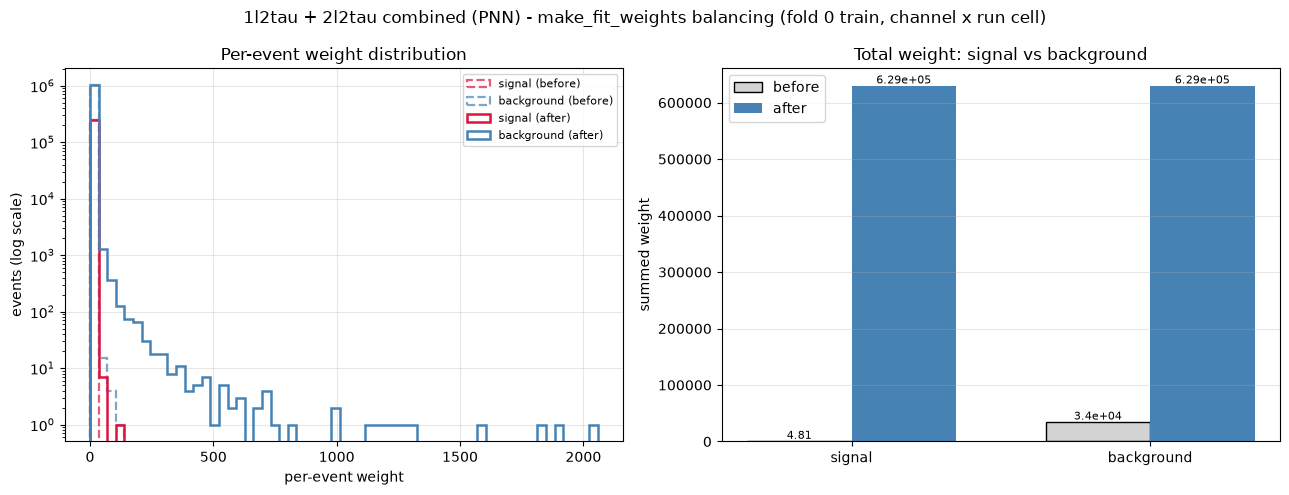

23 features had missing values (globally) -> added 23 __isnan flag columns (final model input width = 85 = 61 features + 1 channel conditioning column(s) + 23 flags)

N_eff (training sample, positive-only, post yield-rescale) by channel x run x label - fold 0:
channel  run  label
1l2tau   2    0         4723.288289
              1        27509.406316
         3    0         2855.269627
              1        52239.009956
2l2tau   2    0          353.731422
              1        16995.671524
         3    0          681.682918
              1        32125.771996
Name: n_eff, dtype: float64

N_eff (eval sample, signed, FULL fold-0 test partition) by channel x run x label:
channel  run  label
1l2tau   2    0          956.475454
              1         7398.000012
         3    0          582.725929
              1        14365.649387
2l2tau   2    0          110.957497
              1         4664.959400
         3    0           69.673133
              1         8675.249182
Name: n_eff,

In [8]:
channel_cols = ["channel_id"]

target_yields = compute_process_yield_targets(data)
flag_cols = compute_flag_cols(data, features)
MODEL_FEATURES = features + channel_cols

BASE_DIR_COMBINED = Path("PPSSP_2026/pnn_channel_combined/combined")
PLOTS_DIR_COMBINED = BASE_DIR_COMBINED / "plots"
PLOTS_DIR_COMBINED.mkdir(parents=True, exist_ok=True)

fd0 = prepare_fold_tensors_pnn(data, features, channel_cols, flag_cols, target_yields,
                                cell_cols=("channel", "run"), n_folds=N_FOLDS, k=0)

w_before = fd0["train_df"]["w_phys"].to_numpy()
w_after = fd0["w_train_fit"]
y_preview = fd0["train_df"]["label"].to_numpy()

plot_weight_balance(
    y_preview, w_before, w_after,
    title="1l2tau + 2l2tau combined (PNN) - make_fit_weights balancing (fold 0 train, channel x run cell)",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedWeightBalance_PNN.png",
)

print(f"{len(flag_cols)} features had missing values (globally) -> added {len(flag_cols)} __isnan flag "
      f"columns (final model input width = {fd0['n_features_model']} = {len(features)} features + "
      f"{len(channel_cols)} channel conditioning column(s) + {len(flag_cols)} flags)")

print("\nN_eff (training sample, positive-only, post yield-rescale) by channel x run x label - fold 0:")
print(n_eff_table(fd0["train_df"], ["channel", "run", "label"]))
print("\nN_eff (eval sample, signed, FULL fold-0 test partition) by channel x run x label:")
print(n_eff_table(fd0["test_df"], ["channel", "run", "label"]))
print(f"\nDropped {fd0['n_dropped_train']} negative-w_phys training rows in this preview fold "
      f"(kept, not abs'd, elsewhere - see prepare_fold_data).")


## PyTorch Dataset & Model (ParameterizedNN)

Architecturally this is an ordinary feed-forward binary classifier - the
"conditioning" comes entirely from the ordinal `channel_id` column being
one extra input dimension concatenated at the input layer (the standard
first thing to try), not from any special layer or loss. If the
"Parameterized Inference Validation" section's sensitivity check later
shows the network barely responds to this column among ~70 inputs,
the next things to try are conditioning at every hidden layer or FiLM
(a small network mapping the flags to per-layer scale/shift) - not
attempted in this first pass. `hidden_sizes=(256, 128)` is the default
architecture used for the fold-0 preview baseline below; the "Optuna
Hyperparameter Search" section further down tunes it (and dropout/lr/
weight_decay/batch_size/patience) properly before the K-Fold Production
Run.


In [9]:
# Model input is small enough to comfortably fit in GPU memory - keep it
# resident there for the whole run instead of using a DataLoader, which
# would otherwise copy every mini-batch host->device one at a time. Batches
# are then just GPU-side tensor indexing (see run_epoch). GPU tensors
# themselves now live inside each fold's `prepare_fold_tensors_pnn` dict
# (fd["X_train_t"], etc.) rather than as fixed globals - `fd0` (fold 0) is
# the representative preview used throughout this notebook until the
# K-Fold Production Run section.

BATCH_SIZE = 8192

DEFAULT_HIDDEN_SIZES = (256, 128)


class ParameterizedNN(nn.Module):

    """
    Mechanically an ordinary feed-forward binary classifier (hidden layers
    with ReLU + dropout, single output logit paired with
    BCEWithLogitsLoss) - the class name is kept for continuity with the
    sibling model notebooks, but this is conditional multi-channel
    training, not a true interpolating PNN (see intro markdown). Its input
    already includes the ordinal channel column (`channel_id`) as an
    ordinary extra column - there is nothing conditioning-specific in
    the architecture itself (input-concat only for this first pass).
    """

    def __init__(self, n_features, hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3):

        super().__init__()
        layers = []
        in_size = n_features

        for hidden_size in hidden_sizes:

            layers += [nn.Linear(in_size, hidden_size), nn.ReLU(), nn.Dropout(dropout)]
            in_size = hidden_size

        layers.append(nn.Linear(in_size, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_model(hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, n_features=None):

    """
    Factory so a hyperparameter search (or a feature-subset retrain) can
    build a fresh model per trial without repeating the
    ParameterizedNN(...).to(DEVICE) boilerplate. `n_features` defaults to
    the fold-0 preview's full input width (physics features + channel
    conditioning column(s) + missingness flags).
    """

    if n_features is None:
        n_features = fd0["n_features_model"]
    return ParameterizedNN(n_features=n_features, hidden_sizes=hidden_sizes, dropout=dropout).to(DEVICE)


model = build_model()

print(model)


ParameterizedNN(
  (net): Sequential(
    (0): Linear(in_features=85, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


## Training Loop

Weighted binary cross-entropy (per-sample weights folded in manually, since
`BCEWithLogitsLoss` has no built-in sample-weight argument), Adam optimizer,
early stopping on weighted validation AUC.


In [10]:
N_EPOCHS = 50
PATIENCE = 10
LEARNING_RATE = 1e-3


def run_epoch(model, X, y, w, criterion, optimizer, train, batch_size=BATCH_SIZE):

    """
    One pass over the GPU-resident tensors (X, y, w), split into
    `batch_size` chunks via plain tensor indexing (no DataLoader). Loss/
    predictions are only pulled to the CPU once, at the very end of the
    epoch, instead of calling `.item()`/`.cpu()` inside the loop (which
    would force a CPU<->GPU sync every mini-batch and stall the GPU).
    """

    model.train(train)
    n = X.shape[0]
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)

    total_loss = torch.zeros((), device=DEVICE)
    total_weight = torch.zeros((), device=DEVICE)
    all_labels, all_probs, all_weights = [], [], []

    with torch.set_grad_enabled(train):
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            xb, yb, wb = X[idx], y[idx], w[idx]

            logits = model(xb)
            loss = (criterion(logits, yb) * wb).sum() / wb.sum()

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.detach() * wb.sum()
            total_weight += wb.sum()
            all_labels.append(yb.detach())
            all_probs.append(torch.sigmoid(logits).detach())
            all_weights.append(wb.detach())

    labels = torch.cat(all_labels).cpu().numpy()
    probs = torch.cat(all_probs).cpu().numpy()
    weights = torch.cat(all_weights).cpu().numpy()

    auc = roc_auc_score(labels, probs, sample_weight=weights)

    return (total_loss / total_weight).item(), auc


def train_model(X_train_data, y_train_data, w_train_data, X_val_data, y_val_data, w_val_data,
                 hidden_sizes=DEFAULT_HIDDEN_SIZES, dropout=0.3, lr=LEARNING_RATE, weight_decay=0.0,
                 batch_size=BATCH_SIZE, n_epochs=N_EPOCHS, patience=PATIENCE, verbose=True,
                 w_train_eval_data=None):

    """
    Build a fresh ParameterizedNN(hidden_sizes, dropout) and train it with
    early stopping on weighted validation AUC. All data args are REQUIRED
    (no more defaulting to fixed module-level globals) since every fold
    (from `prepare_fold_tensors_pnn`) has its own tensors.

    Every epoch also runs an EVAL-MODE pass over the training data (dropout
    off, plain |w_phys| weights via `w_train_eval_data`, defaults to
    `w_train_data`) - "train_auc_eval"/"train_loss_eval" are directly
    comparable to the val curve (dropout off, |w_phys|), unlike the
    dropout-ON "train_auc"/"train_loss" the optimizer actually sees.

    Returns (model, history, best_val_auc, best_train_auc, best_train_auc_eval)
    - `model` already has the best-epoch weights loaded.
    """

    w_train_eval_data = w_train_data if w_train_eval_data is None else w_train_eval_data

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_auc": [], "val_auc": [],
               "train_loss_eval": [], "train_auc_eval": []}
    best_val_auc, best_train_auc, best_train_auc_eval = -np.inf, None, None
    best_state, epochs_no_improve = None, 0

    for epoch in range(1, n_epochs + 1):

        train_loss, train_auc = run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True, batch_size=batch_size)
        train_loss_eval, train_auc_eval = run_epoch(trial_model, X_train_data, y_train_data, w_train_eval_data, criterion, optimizer, train=False, batch_size=batch_size)
        val_loss, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False, batch_size=batch_size)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_auc"].append(train_auc)
        history["val_auc"].append(val_auc)
        history["train_loss_eval"].append(train_loss_eval)
        history["train_auc_eval"].append(train_auc_eval)

        if verbose:
            print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
                  f"| train_auc={train_auc:.4f} train_auc_eval={train_auc_eval:.4f} val_auc={val_auc:.4f}")

        if val_auc > best_val_auc:
            best_val_auc, best_train_auc, best_train_auc_eval = val_auc, train_auc, train_auc_eval
            best_state, epochs_no_improve = {k: v.clone() for k, v in trial_model.state_dict().items()}, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val_auc={best_val_auc:.4f})")
                break

    trial_model.load_state_dict(best_state)
    return trial_model, history, best_val_auc, best_train_auc, best_train_auc_eval


# ---- Fold-0 preview baseline (default hyperparameters) - used only to rank
# features for the correlation-pruning stage below, before Optuna tuning.
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(
    fd0["X_train_t"], fd0["y_train_t"], fd0["w_train_fit_t"],
    fd0["X_val_t"], fd0["y_val_t"], fd0["w_val_abs_t"],
    hidden_sizes=DEFAULT_HIDDEN_SIZES, w_train_eval_data=fd0["w_train_abs_t"],
)

print(f"\nBest val_auc = {best_val_auc:.4f} | train_auc (dropout on) = {best_train_auc:.4f} "
      f"| train_auc_eval (dropout off, comparable) = {best_train_auc_eval:.4f}")


Epoch   1 | train_loss=0.4327 val_loss=0.3575 | train_auc=0.8851 train_auc_eval=0.9143 val_auc=0.9130
Epoch   2 | train_loss=0.3889 val_loss=0.4063 | train_auc=0.9103 train_auc_eval=0.9232 val_auc=0.9209
Epoch   3 | train_loss=0.3681 val_loss=0.3628 | train_auc=0.9166 train_auc_eval=0.9265 val_auc=0.9230
Epoch   4 | train_loss=0.3681 val_loss=0.3384 | train_auc=0.9178 train_auc_eval=0.9286 val_auc=0.9237
Epoch   5 | train_loss=0.3576 val_loss=0.3465 | train_auc=0.9212 train_auc_eval=0.9319 val_auc=0.9263
Epoch   6 | train_loss=0.3523 val_loss=0.3618 | train_auc=0.9236 train_auc_eval=0.9325 val_auc=0.9267
Epoch   7 | train_loss=0.3470 val_loss=0.3534 | train_auc=0.9259 train_auc_eval=0.9347 val_auc=0.9280
Epoch   8 | train_loss=0.3451 val_loss=0.3472 | train_auc=0.9267 train_auc_eval=0.9348 val_auc=0.9279
Epoch   9 | train_loss=0.3407 val_loss=0.3659 | train_auc=0.9286 train_auc_eval=0.9368 val_auc=0.9299
Epoch  10 | train_loss=0.3392 val_loss=0.3306 | train_auc=0.9293 train_auc_eval=0.

## Optuna Hyperparameter Search

Bayesian search (TPE sampler + median pruning) over `hidden_sizes`,
`dropout`, `lr`, `weight_decay`, `batch_size` and `patience`, scored by mean
expected significance (Asimov Z, high-score tail, `significance_scan`) -
the same objective family every other NN notebook in this project uses
(`DNN.ipynb`, `MLP.ipynb`). Runs on `N_OPTUNA_INNER_FOLDS` folds, jointly
per-`(channel × run × class)`-cell balanced just like the production run;
`trial.report`/pruning happens per-EPOCH. Hyperparameters are frozen once
here and reused for both the correlation-pruning retrains below and the
final `N_FOLDS`-fold OOF production run (`run_kfold_pnn`).


/tmp/ipykernel_205384/3769161030.py:85: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),


  0%|          | 0/15 [00:00<?, ?it/s]


[pnn_opt_combined] completed trials: 15
[pnn_opt_combined] best mean CV significance Z (2 eventNumber-folds): 0.18034
[pnn_opt_combined] best parameters:
    hidden_sizes: 256_256_128_128_64_32
    dropout: 0.12047500772435392
    lr: 0.005644750458601329
    weight_decay: 6.543823181156486e-06
    batch_size: 16384
    patience: 12


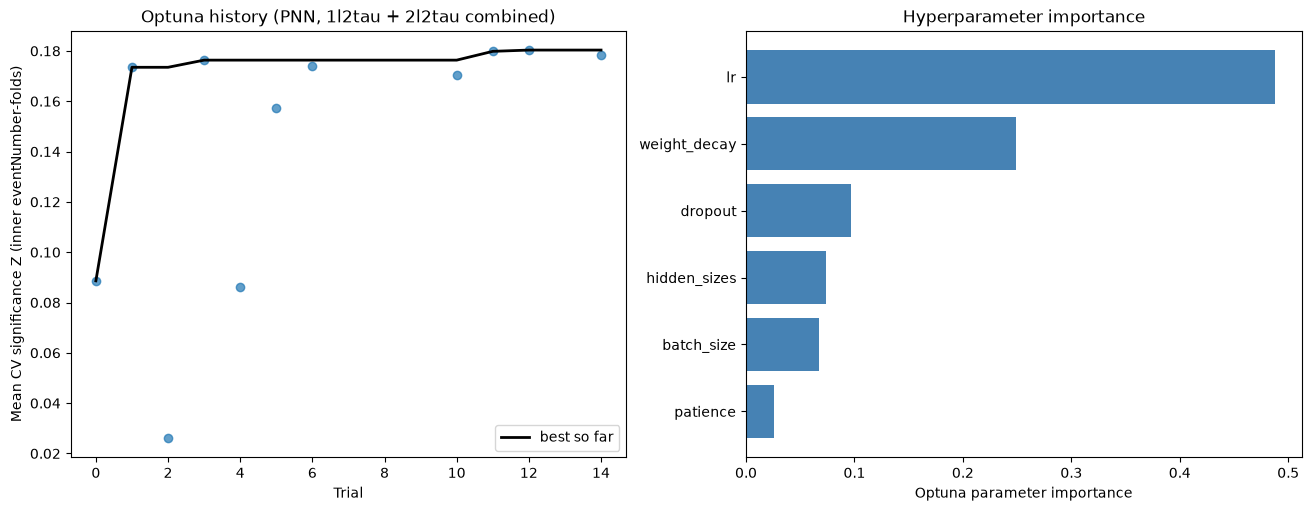


Tuned fold-0 preview: val_auc=0.9342 | hidden_sizes=(256, 256, 128, 128, 64, 32)


In [11]:
def train_model_for_search(trial, step_offset, hidden_sizes, dropout, lr, weight_decay,
                            batch_size, patience, X_train_data, y_train_data, w_train_data,
                            X_val_data, y_val_data, w_val_data, w_val_signed, n_epochs=40):

    """
    Optuna-search-only training loop: same architecture/early-stopping
    convention as `train_model`, but additionally reports the per-EPOCH
    validation significance (Asimov Z) to `trial` and raises
    `optuna.TrialPruned()` if the pruner says to stop. `step_offset` lets
    the caller give every fold's epochs a distinct, monotonically
    increasing `step` within the same trial. Returns the best-epoch
    significance Z reached in this fold.
    """

    trial_model = build_model(hidden_sizes=hidden_sizes, dropout=dropout, n_features=X_train_data.shape[1])
    criterion = nn.BCEWithLogitsLoss(reduction="none")
    optimizer = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_auc, best_z, epochs_no_improve = -np.inf, 0.0, 0

    for epoch in range(1, n_epochs + 1):
        run_epoch(trial_model, X_train_data, y_train_data, w_train_data, criterion, optimizer, train=True, batch_size=batch_size)
        _, val_auc = run_epoch(trial_model, X_val_data, y_val_data, w_val_data, criterion, optimizer, train=False, batch_size=batch_size)

        trial_model.eval()
        with torch.no_grad():
            val_scores = torch.sigmoid(trial_model(X_val_data)).cpu().numpy()
        z, _ = significance_scan(y_val_data.cpu().numpy(), val_scores, w_val_signed)

        trial.report(z, step=step_offset + epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_auc > best_val_auc:
            best_val_auc, best_z, epochs_no_improve = val_auc, z, 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                break

    return best_z, epoch


def run_optuna_search_pnn(data, features, channel_cols, flag_cols, target_yields, cell_cols=("channel", "run"),
                           n_trials=N_OPTUNA_TRIALS, n_inner_folds=N_OPTUNA_INNER_FOLDS,
                           n_epochs=40, study_name="pnn_opt", seed=RANDOM_STATE):

    """
    Bayesian hyperparameter search, identical in spirit to `DNN.ipynb`'s
    `run_optuna_search_nn`, extended to prepare each inner fold with
    `prepare_fold_tensors_pnn` (channel_id conditioning column + per-
    `(channel x run x class)`-cell weight balancing). KNOWN, ACCEPTED LEAK -
    NOT NESTED CV (same caveat as the XGBoost pipelines / DNN.ipynb).
    """

    def objective(trial):
        hidden_choice = trial.suggest_categorical(
            "hidden_sizes", ["64", "128_64", "256_128", "128_64_32", "256_256_128_128_64_32"]
        )
        hidden_sizes = tuple(int(x) for x in hidden_choice.split("_"))
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
        batch_size = trial.suggest_categorical("batch_size", [128, 256, 512, 1024, 2048, 4096, 8192, 16384])
        patience = trial.suggest_int("patience", 5, 15)

        fold_zs, step_offset = [], 0
        for k in range(n_inner_folds):
            fd = prepare_fold_tensors_pnn(data, features, channel_cols, flag_cols, target_yields,
                                           cell_cols=cell_cols, n_folds=N_FOLDS, k=k)
            w_val_signed = fd["val_df"]["w_phys"].to_numpy()
            z, epochs_run = train_model_for_search(
                trial, step_offset, hidden_sizes, dropout, lr, weight_decay, batch_size, patience,
                fd["X_train_t"], fd["y_train_t"], fd["w_train_fit_t"],
                fd["X_val_t"], fd["y_val_t"], fd["w_val_abs_t"], w_val_signed, n_epochs=n_epochs,
            )
            fold_zs.append(z)
            step_offset += epochs_run

        return float(np.mean(fold_zs))

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=seed, multivariate=True),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
        study_name=study_name,
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, gc_after_trial=True)

    print(f"\n[{study_name}] completed trials: {len(study.trials)}")
    print(f"[{study_name}] best mean CV significance Z ({n_inner_folds} eventNumber-folds): {study.best_value:.5f}")
    print(f"[{study_name}] best parameters:")
    for name, value in study.best_params.items():
        print(f"    {name}: {value}")
    return study


def params_from_study_nn(study):

    """Extract the frozen hyperparameter dict from a completed Optuna study."""

    bp = dict(study.best_params)
    bp["hidden_sizes"] = tuple(int(x) for x in bp["hidden_sizes"].split("_"))
    return bp


def plot_optuna_diagnostics_nn(study, title_suffix=""):

    """2-panel diagnostic: Optuna trial history + hyperparameter importance."""

    trials = study.trials_dataframe()
    complete = trials.loc[trials["state"] == "COMPLETE"].copy()
    param_importance = optuna.importance.get_param_importances(study)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    axes[0].plot(complete["number"], complete["value"], "o", alpha=0.7)
    axes[0].plot(complete["number"], complete["value"].cummax(), color="black", linewidth=2, label="best so far")
    axes[0].set(xlabel="Trial", ylabel="Mean CV significance Z (inner eventNumber-folds)", title=f"Optuna history {title_suffix}")
    axes[0].legend()

    names = list(param_importance)
    values = [param_importance[name] for name in names]
    axes[1].barh(names[::-1], values[::-1], color="steelblue")
    axes[1].set(xlabel="Optuna parameter importance", title="Hyperparameter importance")

    plt.show()


study = run_optuna_search_pnn(data, features, channel_cols, flag_cols, target_yields,
                               cell_cols=("channel", "run"), study_name="pnn_opt_combined")
best_params = params_from_study_nn(study)
best_hidden_sizes = best_params["hidden_sizes"]
plot_optuna_diagnostics_nn(study, title_suffix="(PNN, 1l2tau + 2l2tau combined)")

# ---- Refit the fold-0 preview model with the tuned hyperparameters -------
model, history, best_val_auc, best_train_auc, best_train_auc_eval = train_model(
    fd0["X_train_t"], fd0["y_train_t"], fd0["w_train_fit_t"],
    fd0["X_val_t"], fd0["y_val_t"], fd0["w_val_abs_t"],
    hidden_sizes=best_params["hidden_sizes"], dropout=best_params["dropout"],
    lr=best_params["lr"], weight_decay=best_params["weight_decay"],
    batch_size=best_params["batch_size"], patience=best_params["patience"],
    w_train_eval_data=fd0["w_train_abs_t"], verbose=False,
)
print(f"\nTuned fold-0 preview: val_auc={best_val_auc:.4f} | hidden_sizes={best_hidden_sizes}")


## Evaluation

Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedTrainingCurves_PNN.png


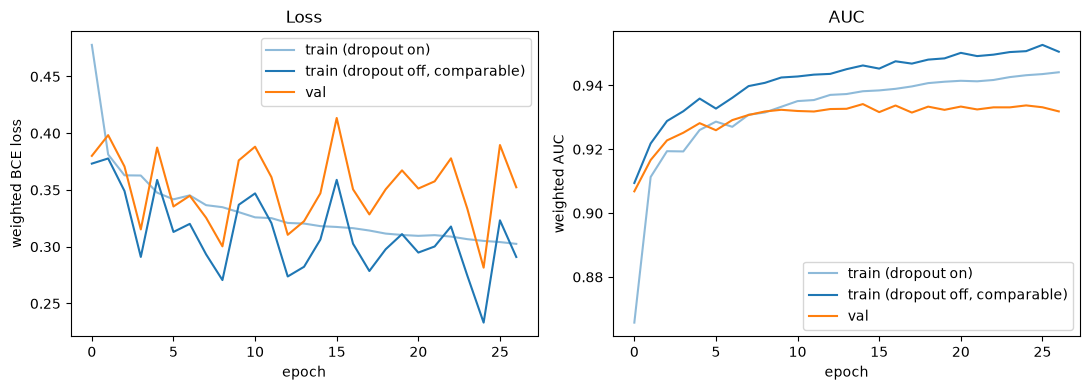

Full (pre-pruning) baseline model (fold-0 preview) - weighted AUC (POOLED across both channels): train=0.9463 val=0.9342
NOTE: a pooled number can be misleading if one channel is intrinsically cleaner than the other - see the per-channel breakdown right below. This is the FULL fold-0-preview baseline model; the 'Correlation Pruning & Retraining'/'Top-15 Features Only' sections below retrain on smaller feature sets, and the 'K-Fold Production Run & Artifacts' section further down produces the actual 5-fold OOF numbers that carry through to the 'Comparison Against Solo-Channel Baselines' section near the end.
Per-channel weighted val AUC (full fold-0-preview baseline model): 1l2tau=0.9299 (361030 events) | 2l2tau=0.9521 (59635 events)
Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedROC_PNN.png


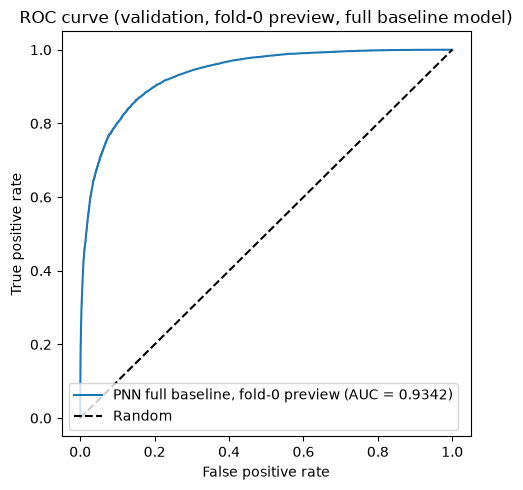

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[0].plot(history["train_loss_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[0].plot(history["val_loss"], label="val", color="tab:orange")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("weighted BCE loss")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history["train_auc"], label="train (dropout on)", color="tab:blue", alpha=0.5)
axes[1].plot(history["train_auc_eval"], label="train (dropout off, comparable)", color="tab:blue")
axes[1].plot(history["val_auc"], label="val", color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("weighted AUC")
axes[1].set_title("AUC")
axes[1].legend()

plt.tight_layout()
fig.savefig(PLOTS_DIR_COMBINED / "ChannelCombinedTrainingCurves_PNN.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_COMBINED / 'ChannelCombinedTrainingCurves_PNN.png'}")
plt.show()

model.eval()
with torch.no_grad():
    train_probs = torch.sigmoid(model(fd0["X_train_t"])).cpu().numpy()
    val_probs = torch.sigmoid(model(fd0["X_val_t"])).cpu().numpy()

y_train = fd0["train_df"]["label"].to_numpy()
y_val = fd0["val_df"]["label"].to_numpy()
w_train_abs = fd0["train_df"]["w_phys"].to_numpy()
w_val_fit = fd0["w_val_abs_t"].cpu().numpy()

auc_train = roc_auc_score(y_train, train_probs, sample_weight=w_train_abs)
auc_val = roc_auc_score(y_val, val_probs, sample_weight=w_val_fit)

print(f"Full (pre-pruning) baseline model (fold-0 preview) - weighted AUC (POOLED across both channels): "
      f"train={auc_train:.4f} val={auc_val:.4f}")
print("NOTE: a pooled number can be misleading if one channel is intrinsically cleaner than the "
      "other - see the per-channel breakdown right below. This is the FULL fold-0-preview baseline "
      "model; the 'Correlation Pruning & Retraining'/'Top-15 Features Only' sections below retrain on "
      "smaller feature sets, and the 'K-Fold Production Run & Artifacts' section further down produces "
      "the actual 5-fold OOF numbers that carry through to the 'Comparison Against Solo-Channel "
      "Baselines' section near the end.")

# Per-channel val AUC breakdown of the FULL fold-0-preview baseline model -
# each event is scored with its OWN true channel_id value here (no
# fixed-hypothesis trick), so this already shows how well the shared
# network does on each channel individually. Suffixed "_full" because the
# pruning stage below retrains smaller models and reassigns the plain
# val_auc_1l2tau/val_auc_2l2tau names to whichever model ends up FINAL
# (top-15).

is_1l2tau_val = (fd0["val_df"]["channel"] == "1l2tau").to_numpy()
is_2l2tau_val = (fd0["val_df"]["channel"] == "2l2tau").to_numpy()
val_auc_1l2tau_full = roc_auc_score(y_val[is_1l2tau_val], val_probs[is_1l2tau_val], sample_weight=w_val_fit[is_1l2tau_val])
val_auc_2l2tau_full = roc_auc_score(y_val[is_2l2tau_val], val_probs[is_2l2tau_val], sample_weight=w_val_fit[is_2l2tau_val])
print(f"Per-channel weighted val AUC (full fold-0-preview baseline model): 1l2tau={val_auc_1l2tau_full:.4f} "
      f"({is_1l2tau_val.sum()} events) | 2l2tau={val_auc_2l2tau_full:.4f} ({is_2l2tau_val.sum()} events)")

fpr, tpr, _ = roc_curve(y_val, val_probs, sample_weight=w_val_fit)
fig = plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"PNN full baseline, fold-0 preview (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve (validation, fold-0 preview, full baseline model)")
plt.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR_COMBINED / "ChannelCombinedROC_PNN.png", dpi=150)
print(f"Saved plot -> {PLOTS_DIR_COMBINED / 'ChannelCombinedROC_PNN.png'}")
plt.show()


## Feature Importance (Permutation)

Model-agnostic **permutation importance**: shuffle one feature's column
across events (destroying its relationship with the rest of the row) and
measure how much the weighted validation AUC drops. `channel_id` is
included as an ordinary entry in `MODEL_FEATURES` here - a large drop
when it is shuffled would confirm the network genuinely uses the channel
conditioning (rather than ignoring it and just relying on the shared
physics features).


Baseline weighted AUC: 0.9342
Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedImportanceFull_PNN.png


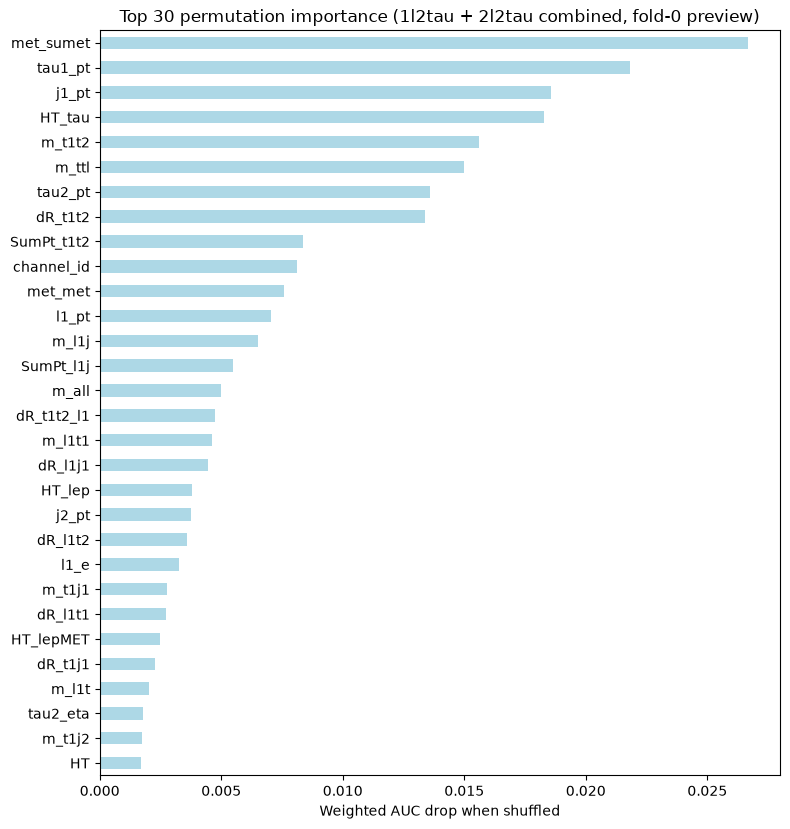

channel_id: rank 10/62, AUC drop = 0.0081


met_sumet     0.026657
tau1_pt       0.021823
j1_pt         0.018575
HT_tau        0.018299
m_t1t2        0.015623
m_ttl         0.014987
tau2_pt       0.013591
dR_t1t2       0.013379
SumPt_t1t2    0.008384
channel_id    0.008118
met_met       0.007564
l1_pt         0.007045
m_l1j         0.006517
SumPt_l1j     0.005472
m_all         0.005005
Name: auc_drop, dtype: float64

In [13]:
def permutation_importance(model, X, y, w, feature_names, n_repeats=5, random_state=RANDOM_STATE):

    """
    Model-agnostic feature importance: for each feature, shuffle its column
    across events `n_repeats` times and measure the average drop in weighted
    AUC relative to the unshuffled baseline. `X`, `y`, `w` must already be
    GPU-resident tensors with columns in the same order as `feature_names`
    (only the FIRST `len(feature_names)` columns of `X` are addressed - any
    trailing `__isnan` flag columns are intentionally left unreported).
    Returns a pandas Series (feature -> mean AUC drop), sorted descending.
    """

    rng = np.random.default_rng(random_state)
    model.eval()

    y_np = y.cpu().numpy()
    w_np = w.cpu().numpy()

    with torch.no_grad():
        baseline_probs = torch.sigmoid(model(X)).cpu().numpy()

    baseline_auc = roc_auc_score(y_np, baseline_probs, sample_weight=w_np)
    print(f"Baseline weighted AUC: {baseline_auc:.4f}")

    mean_drops = []

    for i, feat in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            perm = torch.as_tensor(rng.permutation(X.shape[0]), device=X.device)
            X_perm = X.clone()
            X_perm[:, i] = X_perm[perm, i]

            with torch.no_grad():
                probs = torch.sigmoid(model(X_perm)).cpu().numpy()
            auc = roc_auc_score(y_np, probs, sample_weight=w_np)
            drops.append(baseline_auc - auc)

        mean_drops.append(np.mean(drops))

    return pd.Series(mean_drops, index=feature_names, name="auc_drop").sort_values(ascending=False)


def plot_importance_bar(imp, top_n=30, title="", color="lightblue", save_path=None):

    """
    Horizontal bar chart of the top `top_n` features by importance. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    n = min(top_n, len(imp))

    fig, ax = plt.subplots(figsize=(8, max(4, 0.28 * n)))
    imp.head(top_n)[::-1].plot.barh(ax=ax, color=color)
    ax.set_xlabel("Weighted AUC drop when shuffled")
    ax.set_title(title)
    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


importance = permutation_importance(model, fd0["X_val_t"], fd0["y_val_t"], fd0["w_val_abs_t"], MODEL_FEATURES, n_repeats=5)
plot_importance_bar(importance, top_n=30, title="Top 30 permutation importance (1l2tau + 2l2tau combined, fold-0 preview)",
                     save_path=PLOTS_DIR_COMBINED / "ChannelCombinedImportanceFull_PNN.png")

for col in channel_cols:
    rank = int(importance.index.get_loc(col)) + 1
    print(f"{col}: rank {rank}/{len(importance)}, AUC drop = {importance[col]:.4f}")
importance.head(15)


## Correlation Pruning & Retraining

Mirrors the XGBoost master pipeline's (and the solo MLP/DNN/GNN notebooks')
correlation-pruning stage, so this combined-channel model is judged on the
same "full → pruned → top-15" ladder as its solo-channel baselines (see
the "Comparison Against Solo-Channel Baselines" section below): rank the
**physics** features by permutation importance, look at Pearson correlation
among the top candidates separately for signal and background, then walk
the ranked list keeping a feature only if it isn't too correlated
(`|corr| > 0.75`) with a more important feature already kept. The model is
then retrained from scratch on the decorrelated feature set, and again
restricted to just the top 15 physics features.

**The channel indicator column (`channel_id`) is excluded from the
ranking/pruning candidate pool and the correlation walk, and is
UNCONDITIONALLY re-appended to every pruned/top-15 feature set.** It is
the entire point of this notebook (channel conditioning) - not a redundant
physics input - so it would defeat the purpose to let a generic
importance-ranked pruning step drop it just because it didn't crack
the top 30.


In [14]:
TOP_N_IMPORTANCE = 30   # candidate pool size (physics features only), before correlation pruning
CORR_THRESH = 0.75      # |corr| above this -> considered redundant
N_KEEP = 20             # decorrelated physics features to keep in the main pruned model


def top_pairs(corr, thr=0.70):

    """Feature pairs with |Pearson correlation| > thr, most-correlated first."""

    upper = corr.abs().where(np.triu(np.ones_like(corr, dtype=bool), k=1))
    return upper.stack().sort_values(ascending=False).loc[lambda s: s > thr]


def grouped_correlations(data, feats, group_col, group_values):

    """
    Pearson correlation of `feats`, computed separately for each value of
    `group_col` (label 0/1 = background/signal here) - correlations
    genuinely differ between groups, so pruning must look at both, not just
    the pooled correlation.
    """

    return {v: data.loc[data[group_col] == v, feats].corr() for v in group_values}


def plot_group_correlations(corrs, names, feats, suptitle="", save_path=None):

    """
    Side-by-side correlation heatmaps, one per entry in `corrs`/`names`. If
    `save_path` is given, the figure is written to disk (parent directories
    created as needed, dpi=150) before being displayed.
    """

    fig, axes = plt.subplots(1, len(corrs), figsize=(11 * len(corrs), 10), constrained_layout=True)
    axes = np.atleast_1d(axes)
    im = None
    for ax, corr, name in zip(axes, corrs, names):
        im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="PuOr")
        ax.set_xticks(range(len(feats)))
        ax.set_xticklabels(feats, rotation=90, fontsize=7)
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels(feats, fontsize=7)
        ax.set_title(name)

    fig.colorbar(im, ax=list(axes), shrink=0.8, label="Pearson correlation")

    if suptitle:
        fig.suptitle(suptitle)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot -> {save_path}")

    plt.show()


def prune_correlated(top_feats, corr_max, corr_thresh=CORR_THRESH, n_keep=N_KEEP):

    """
    Walk `top_feats` (most -> least important). Keep a feature unless it is
    more than `corr_thresh` correlated with a more-important feature already
    kept (i.e. it's redundant with something better). Stop once `n_keep`
    survivors are found.
    """

    kept, dropped = [], []
    for feat in top_feats:
        redundant_with = next((k for k in kept if corr_max.loc[feat, k] > corr_thresh), None)
        if redundant_with is None:
            kept.append(feat)
        else:
            dropped.append((feat, redundant_with, corr_max.loc[feat, redundant_with]))
        if len(kept) == n_keep:
            break

    if len(kept) < n_keep:
        print(f"WARNING: only {len(kept)}/{n_keep} survivors found within the top "
              f"{len(top_feats)} candidates - raise the candidate pool or lower corr_thresh.")

    print(f"Kept {len(kept)} decorrelated physics features (most -> least important):")
    for i, feat in enumerate(kept, 1):
        print(f"  {i:2d}. {feat}")
    print(f"\nDropped {len(dropped)} redundant features (|corr| > {corr_thresh} with a more important feature):")
    for feat, because_of, corr_val in dropped:
        print(f"  {feat:15s} -> redundant with {because_of:15s} (|corr| = {corr_val:.3f})")

    return kept, dropped


def subset_feature_tensors_fold(fd, feature_subset, all_features):

    """
    Slice a fold's already-scaled train/val/test GPU tensors (from
    `prepare_fold_tensors_pnn`) down to `feature_subset` (columns picked by
    name, matching `all_features`'s order) - the __isnan flag columns (if
    any) are intentionally dropped, matching this notebook's original
    correlation-pruning behavior. `feature_subset` is expected to already
    include the channel conditioning column where relevant (it's never
    dropped - see markdown above), so this function itself has no
    special-casing for it.
    """

    idx = [all_features.index(f) for f in feature_subset]
    idx_t = torch.as_tensor(idx, device=DEVICE)
    return fd["X_train_t"][:, idx_t], fd["X_val_t"][:, idx_t], fd["X_test_t"][:, idx_t]


Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedCorrelationTop30_PNN.png


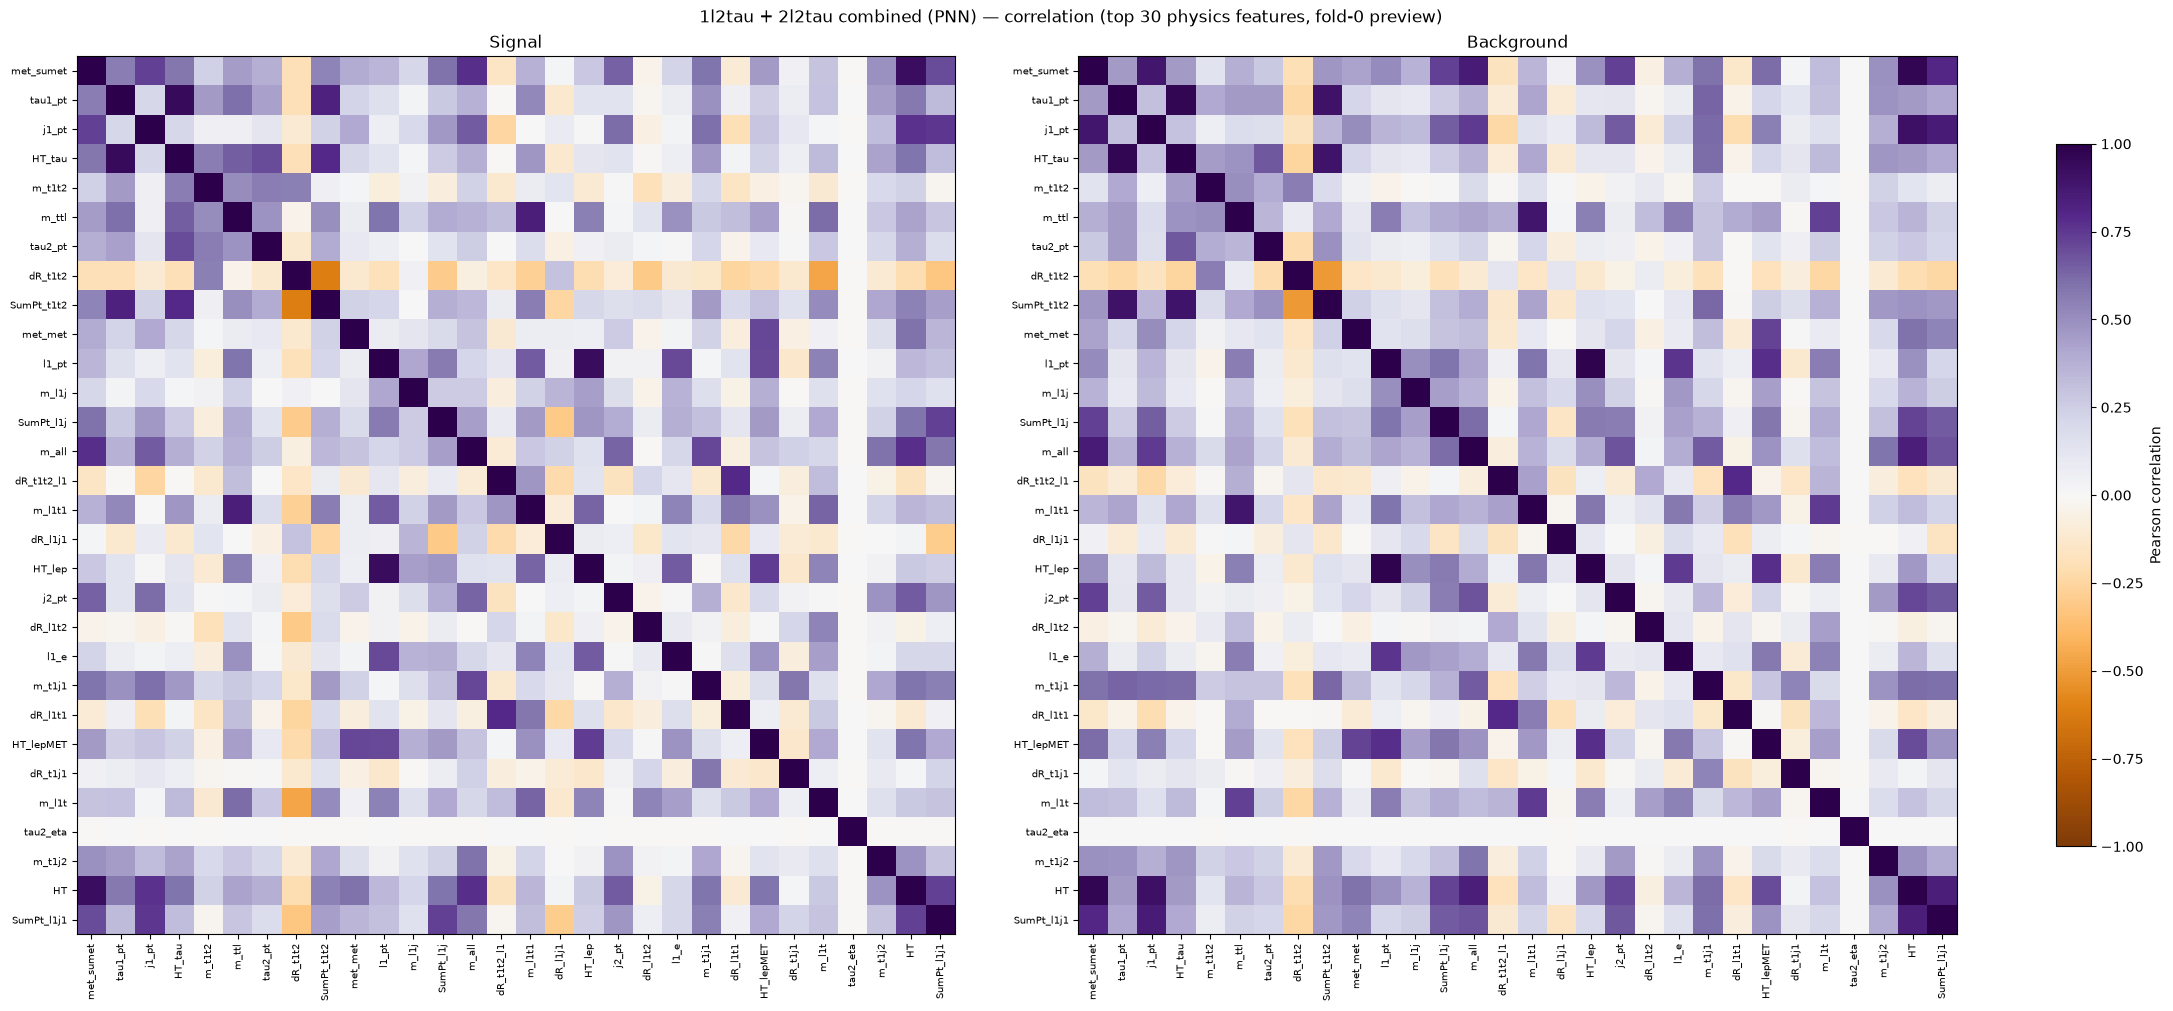

Pairs with |corr| > 0.50 (signal):
tau1_pt     HT_tau        0.945050
l1_pt       HT_lep        0.936126
met_sumet   HT            0.929207
m_ttl       m_l1t1        0.841045
tau1_pt     SumPt_t1t2    0.823732
HT_tau      SumPt_t1t2    0.792148
dR_t1t2_l1  dR_l1t1       0.791333
m_all       HT            0.780627
met_sumet   m_all         0.780349
j1_pt       HT            0.767878
            SumPt_l1j1    0.753064
HT_lep      HT_lepMET     0.739113
SumPt_l1j   SumPt_l1j1    0.729236
HT          SumPt_l1j1    0.727677
met_sumet   j1_pt         0.727547
met_met     HT_lepMET     0.716579
m_all       m_t1j1        0.714846
l1_pt       l1_e          0.709058
            HT_lepMET     0.706351
HT_tau      tau2_pt       0.703043
met_sumet   SumPt_l1j1    0.701177

Pairs with |corr| > 0.50 (background):
l1_pt       HT_lep        0.981780
tau1_pt     HT_tau        0.967344
met_sumet   HT            0.963736
j1_pt       HT            0.908456
tau1_pt     SumPt_t1t2    0.902758
HT_tau      Sum

In [15]:
# ---- Correlation of the top-30 permutation-important PHYSICS features -----
# The channel conditioning column is excluded from this ranking/pruning
# candidate pool (see markdown above) - it's always kept regardless of rank.
# Correlation is computed on the fold-0 TRAIN split only (not the full
# `data`, which would leak val/test rows into the correlation estimate -
# matches DNN.ipynb's equivalent cell).

physics_importance = importance.drop(index=channel_cols)
top_feats = physics_importance.index[:TOP_N_IMPORTANCE].tolist()
corrs = grouped_correlations(fd0["train_df"], top_feats, group_col="label", group_values=[1, 0])

plot_group_correlations(
    [corrs[1], corrs[0]], ["Signal", "Background"], top_feats,
    suptitle=f"1l2tau + 2l2tau combined (PNN) — correlation (top {TOP_N_IMPORTANCE} physics features, fold-0 preview)",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedCorrelationTop30_PNN.png",
)

print("Pairs with |corr| > 0.50 (signal):")
print(top_pairs(corrs[1]).to_string())
print("\nPairs with |corr| > 0.50 (background):")
print(top_pairs(corrs[0]).to_string())


In [16]:
# ---- Correlation-based pruning to a decorrelated top-20 (physics only) -----
# Conservative combination: a pair counts as redundant if EITHER regime
# (signal or background) shows near-degeneracy.

corr_max = corrs[1].abs().combine(corrs[0].abs(), np.maximum)
PRUNED_FEATURES, dropped_features = prune_correlated(top_feats, corr_max, CORR_THRESH, N_KEEP)

# The channel indicator column is UNCONDITIONALLY re-appended (never pruned) -
# see the intro markdown and the section markdown above.
PRUNED_MODEL_FEATURES = PRUNED_FEATURES + channel_cols
print(f"\n+ {len(channel_cols)} channel conditioning column(s) (always retained, not part of the pruning "
      f"candidate pool): {channel_cols}")


Kept 19 decorrelated physics features (most -> least important):
   1. met_sumet
   2. tau1_pt
   3. m_t1t2
   4. m_ttl
   5. tau2_pt
   6. dR_t1t2
   7. met_met
   8. l1_pt
   9. m_l1j
  10. SumPt_l1j
  11. dR_t1t2_l1
  12. dR_l1j1
  13. j2_pt
  14. dR_l1t2
  15. m_t1j1
  16. dR_t1j1
  17. m_l1t
  18. tau2_eta
  19. m_t1j2

Dropped 11 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.880)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  m_all           -> redundant with met_sumet       (|corr| = 0.858)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.883)
  HT_lep          -> redundant with l1_pt           (|corr| = 0.982)
  l1_e            -> redundant with l1_pt           (|corr| = 0.761)
  dR_l1t1         -> redundant with dR_t1t2_l1      (|corr| = 0.795)
  HT_lepMET       -> redundant with l1_pt   

Full model   (62 features incl. channel conditioning): train_auc_eval = 0.9463 | val_auc (pooled) = 0.9342
Pruned model (20 features incl. channel conditioning): train_auc_eval = 0.9442 | val_auc (pooled) = 0.9357
Baseline weighted AUC: 0.9357
Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedImportancePruned_PNN.png


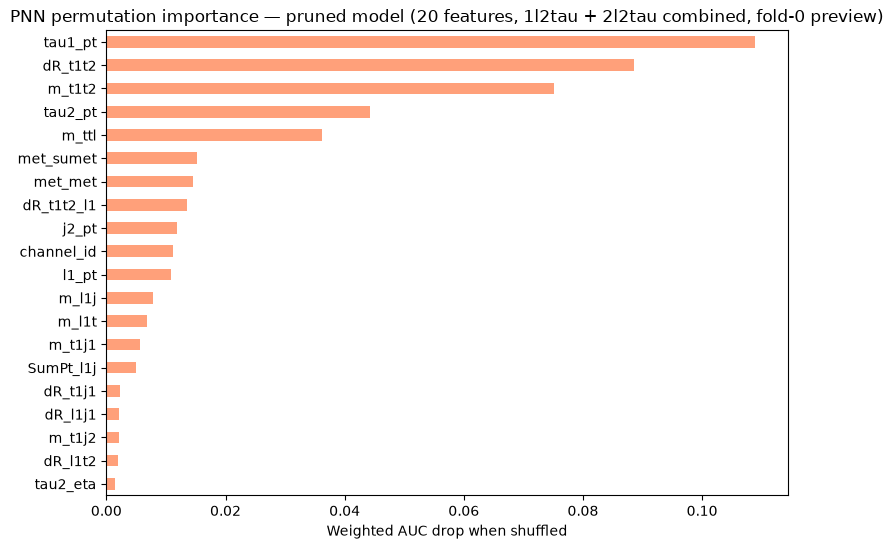

Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedCorrelationPruned_PNN.png


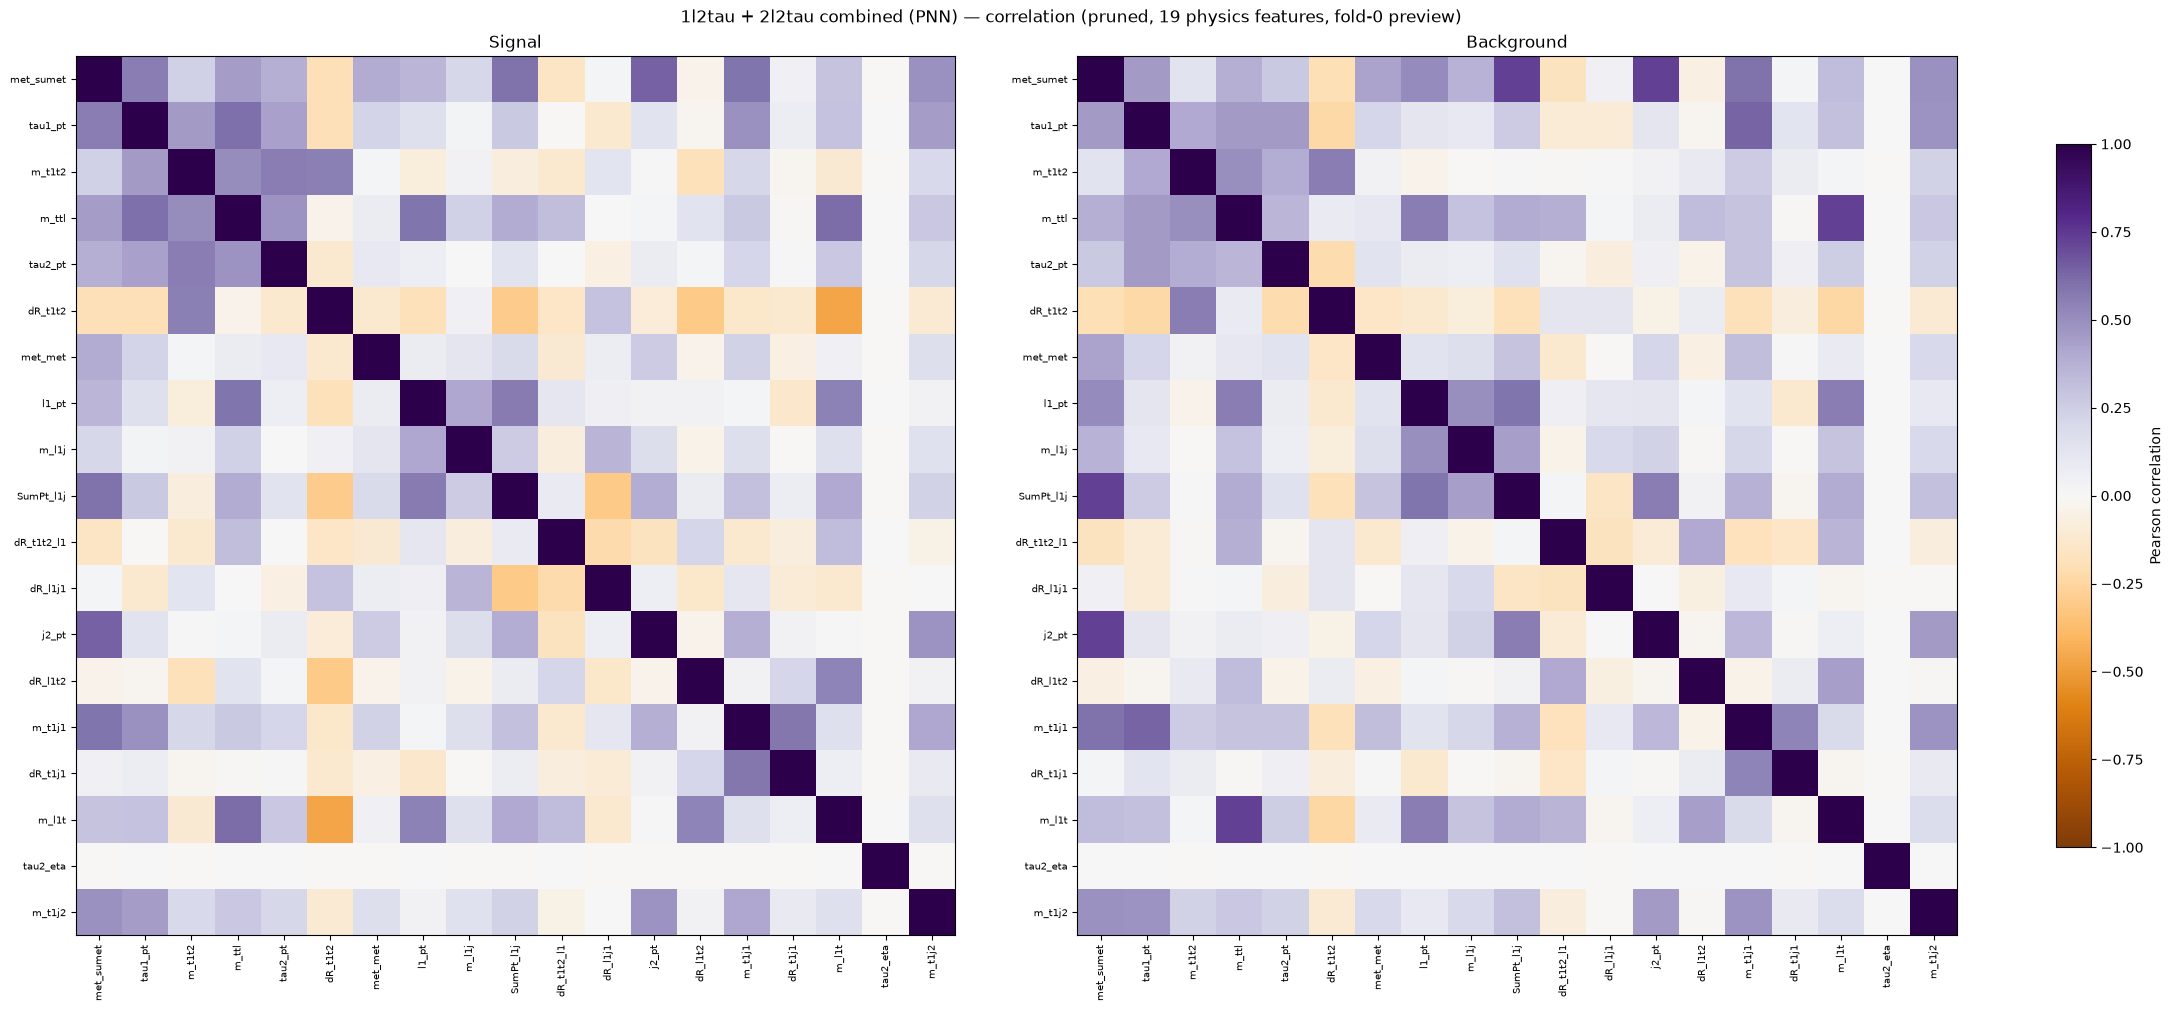

In [17]:
# ---- Retrain on the pruned feature set (physics pruned + channel conditioning, fold-0 preview) --
X_train_pruned_t, X_val_pruned_t, X_test_pruned_t = subset_feature_tensors_fold(fd0, PRUNED_MODEL_FEATURES, MODEL_FEATURES)

model_pruned, history_pruned, val_auc_pruned, train_auc_pruned, train_auc_eval_pruned = train_model(
    X_train_pruned_t, fd0["y_train_t"], fd0["w_train_fit_t"],
    X_val_pruned_t, fd0["y_val_t"], fd0["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes, dropout=best_params["dropout"], lr=best_params["lr"],
    weight_decay=best_params["weight_decay"], batch_size=best_params["batch_size"],
    patience=best_params["patience"], w_train_eval_data=fd0["w_train_abs_t"], verbose=False,
)

print(f"Full model   ({len(MODEL_FEATURES):2d} features incl. channel conditioning): "
      f"train_auc_eval = {best_train_auc_eval:.4f} | val_auc (pooled) = {best_val_auc:.4f}")
print(f"Pruned model ({len(PRUNED_MODEL_FEATURES):2d} features incl. channel conditioning): "
      f"train_auc_eval = {train_auc_eval_pruned:.4f} | val_auc (pooled) = {val_auc_pruned:.4f}")

importance_pruned = permutation_importance(model_pruned, X_val_pruned_t, fd0["y_val_t"], fd0["w_val_abs_t"], PRUNED_MODEL_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_pruned, top_n=len(PRUNED_MODEL_FEATURES),
    title=f"PNN permutation importance — pruned model ({len(PRUNED_MODEL_FEATURES)} features, "
          f"1l2tau + 2l2tau combined, fold-0 preview)",
    color="lightsalmon",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedImportancePruned_PNN.png",
)

pruned_corrs = grouped_correlations(fd0["train_df"], PRUNED_FEATURES, group_col="label", group_values=[1, 0])
plot_group_correlations(
    [pruned_corrs[1], pruned_corrs[0]], ["Signal", "Background"], PRUNED_FEATURES,
    suptitle=f"1l2tau + 2l2tau combined (PNN) — correlation (pruned, {len(PRUNED_FEATURES)} physics features, fold-0 preview)",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedCorrelationPruned_PNN.png",
)


## Top-15 Features Only

Same correlation-pruning walk over the same top-30 physics candidate pool,
but stopped once 15 decorrelated physics features are kept (plus the
channel indicator column, always retained - see the intro markdown and the
"Correlation Pruning & Retraining" section above), to see how much (if any)
weighted validation AUC is lost by cutting down to a much smaller,
easier-to-interpret feature set. **This top-15 model becomes the
notebook's FINAL model**, scored once on the held-out test set below -
matching the convention the solo XGBoost/MLP/DNN/GNN notebooks already use
for their own "Combined" row in `model_summary_*.csv`, so the "Comparison
Against Solo-Channel Baselines" section stays an apples-to-apples,
top-15-vs-top-15 comparison.



Kept 15 decorrelated physics features (most -> least important):
   1. met_sumet
   2. tau1_pt
   3. m_t1t2
   4. m_ttl
   5. tau2_pt
   6. dR_t1t2
   7. met_met
   8. l1_pt
   9. m_l1j
  10. SumPt_l1j
  11. dR_t1t2_l1
  12. dR_l1j1
  13. j2_pt
  14. dR_l1t2
  15. m_t1j1

Dropped 7 redundant features (|corr| > 0.75 with a more important feature):
  j1_pt           -> redundant with met_sumet       (|corr| = 0.880)
  HT_tau          -> redundant with tau1_pt         (|corr| = 0.967)
  SumPt_t1t2      -> redundant with tau1_pt         (|corr| = 0.903)
  m_all           -> redundant with met_sumet       (|corr| = 0.858)
  m_l1t1          -> redundant with m_ttl           (|corr| = 0.883)
  HT_lep          -> redundant with l1_pt           (|corr| = 0.982)
  l1_e            -> redundant with l1_pt           (|corr| = 0.761)
Baseline weighted AUC: 0.9347
Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedImportanceTop15_PNN.png


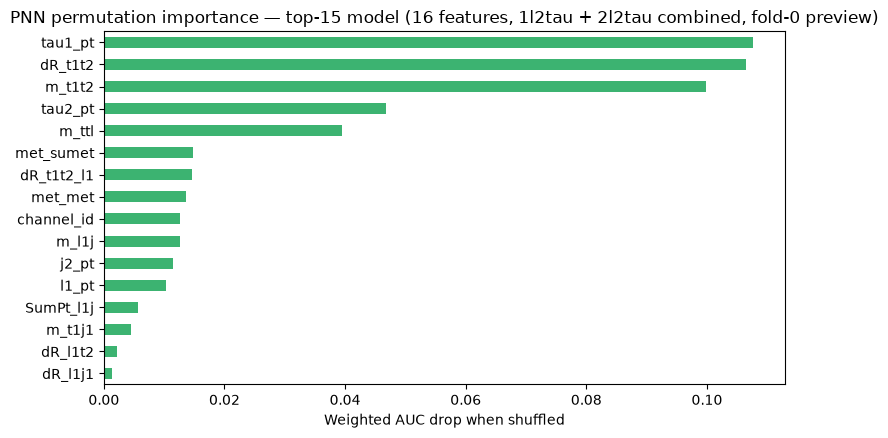


Weighted train(eval-mode)/validation AUC comparison (fold-0 preview; pooled + per-channel; every row includes all 1 channel conditioning column(s), never pruned):


,model,train_auc_eval,val_auc (pooled),val_auc_1l2tau,val_auc_2l2tau
1,Pruned (20 features),0.944241,0.935706,0.931139,0.958428
2,Top-15 (16 features),0.943331,0.934663,0.929647,0.958874
0,Full (62 features),0.946253,0.934156,0.929852,0.952094


In [18]:
TOP15_FEATURES, dropped_top15 = prune_correlated(top_feats, corr_max, CORR_THRESH, n_keep=15)
TOP15_MODEL_FEATURES = TOP15_FEATURES + channel_cols

X_train_top15_t, X_val_top15_t, X_test_top15_t = subset_feature_tensors_fold(fd0, TOP15_MODEL_FEATURES, MODEL_FEATURES)

model_top15, history_top15, val_auc_top15, train_auc_top15, train_auc_eval_top15 = train_model(
    X_train_top15_t, fd0["y_train_t"], fd0["w_train_fit_t"],
    X_val_top15_t, fd0["y_val_t"], fd0["w_val_abs_t"],
    hidden_sizes=best_hidden_sizes, dropout=best_params["dropout"], lr=best_params["lr"],
    weight_decay=best_params["weight_decay"], batch_size=best_params["batch_size"],
    patience=best_params["patience"], w_train_eval_data=fd0["w_train_abs_t"], verbose=False,
)

importance_top15 = permutation_importance(model_top15, X_val_top15_t, fd0["y_val_t"], fd0["w_val_abs_t"], TOP15_MODEL_FEATURES, n_repeats=5)
plot_importance_bar(
    importance_top15, top_n=len(TOP15_MODEL_FEATURES),
    title=f"PNN permutation importance — top-15 model ({len(TOP15_MODEL_FEATURES)} features, "
          f"1l2tau + 2l2tau combined, fold-0 preview)",
    color="mediumseagreen",
    save_path=PLOTS_DIR_COMBINED / "ChannelCombinedImportanceTop15_PNN.png",
)


def per_channel_val_auc(scores):
    """Weighted val AUC restricted to each channel's own events (fold-0
    preview) - the per-model version of the per-channel breakdown the intro
    markdown's 'Evaluation: pooled AUC will lie' section insists on."""
    auc_1l2tau = roc_auc_score(y_val[is_1l2tau_val], scores[is_1l2tau_val], sample_weight=w_val_fit[is_1l2tau_val])
    auc_2l2tau = roc_auc_score(y_val[is_2l2tau_val], scores[is_2l2tau_val], sample_weight=w_val_fit[is_2l2tau_val])
    return auc_1l2tau, auc_2l2tau


model_pruned.eval()
with torch.no_grad():
    val_probs_pruned = torch.sigmoid(model_pruned(X_val_pruned_t)).cpu().numpy()
model_top15.eval()
with torch.no_grad():
    val_probs_top15 = torch.sigmoid(model_top15(X_val_top15_t)).cpu().numpy()

val_auc_1l2tau_pruned, val_auc_2l2tau_pruned = per_channel_val_auc(val_probs_pruned)
val_auc_1l2tau_top15, val_auc_2l2tau_top15 = per_channel_val_auc(val_probs_top15)

comparison = pd.DataFrame([
    {"model": f"Full ({len(MODEL_FEATURES)} features)", "train_auc_eval": best_train_auc_eval,
     "val_auc (pooled)": best_val_auc,
     "val_auc_1l2tau": val_auc_1l2tau_full, "val_auc_2l2tau": val_auc_2l2tau_full},
    {"model": f"Pruned ({len(PRUNED_MODEL_FEATURES)} features)", "train_auc_eval": train_auc_eval_pruned,
     "val_auc (pooled)": val_auc_pruned,
     "val_auc_1l2tau": val_auc_1l2tau_pruned, "val_auc_2l2tau": val_auc_2l2tau_pruned},
    {"model": f"Top-15 ({len(TOP15_MODEL_FEATURES)} features)", "train_auc_eval": train_auc_eval_top15,
     "val_auc (pooled)": val_auc_top15,
     "val_auc_1l2tau": val_auc_1l2tau_top15, "val_auc_2l2tau": val_auc_2l2tau_top15},
]).sort_values("val_auc (pooled)", ascending=False)

print("\nWeighted train(eval-mode)/validation AUC comparison (fold-0 preview; pooled + per-channel; "
      f"every row includes all {len(channel_cols)} channel conditioning column(s), never pruned):")
comparison


## Physics Figure of Merit

Weighted AUC is a global ranking metric; for HH what matters is significance
in the high-score region. This reports a max-Asimov-significance scan on
**VAL** (fold-0 preview, used for model/cut selection) for the **final
model** - the top-15 (physics) + channel indicator model from the pruning
walk above, the most decorrelated/interpretable feature set, matching the
convention the solo XGBoost/MLP/DNN/GNN notebooks use for their own final
model (see `models_registry`/`best_name` below).

A genuinely blind estimate follows in the "K-Fold Production Run &
Artifacts" section below: `best_params` (Optuna-tuned) and
`FINAL_MODEL_FEATURES` (top-15 + channel indicator) are frozen here and
reused to train one model per outer fold (`run_kfold_pnn`), scoring every
event with a model that never trained on it. The fold-0-preview VAL-selected
score cut (`thr_val`) is then applied FROZEN to those out-of-fold (OOF)
scores, reporting pooled and per-channel OOF AUC/Z exactly once - there is
no single held-out test partition anymore, only the pooled + per-channel
OOF metrics.


In [19]:
# ---- Score the FINAL model (top-15 physics features + channel indicator) -
# the most decorrelated/interpretable feature set from the pruning walk
# above (fold-0 preview) - matching the convention the solo XGBoost/MLP/
# DNN/GNN notebooks use for their own "Combined" row (see the "Comparison
# Against Solo-Channel Baselines" section near the end). significance_scan
# is the canonical copy from the K-Fold helper library above.
models_registry = {
    f"Full ({len(MODEL_FEATURES)} features)": (model, fd0["X_val_t"], fd0["X_test_t"]),
    f"Pruned ({len(PRUNED_MODEL_FEATURES)} features)": (model_pruned, X_val_pruned_t, X_test_pruned_t),
    f"Top-15 ({len(TOP15_MODEL_FEATURES)} features)": (model_top15, X_val_top15_t, X_test_top15_t),
}
best_name = f"Top-15 ({len(TOP15_MODEL_FEATURES)} features)"

final_model, X_val_final_t, X_test_final_t = models_registry[best_name]
FINAL_MODEL_FEATURES = TOP15_MODEL_FEATURES  # keep the name<->feature-list mapping explicit

final_model.eval()
with torch.no_grad():
    val_scores = torch.sigmoid(final_model(X_val_final_t)).cpu().numpy()

w_val_signed = fd0["val_df"]["w_phys"].to_numpy()  # signed - expected yields
z_val, thr_val = significance_scan(y_val, val_scores, w_val_signed)

# These now become the canonical "val_auc_1l2tau"/"val_auc_2l2tau" names the
# rest of the notebook (K-Fold Production Run, Parameterized Inference
# Validation, Comparison Against Solo-Channel Baselines, Final Summary,
# Export) already reads - i.e. everything downstream reports the FINAL
# (top-15) model, not the full fold-0-preview baseline model from the
# "Evaluation" section above (that one is preserved under the "_full" suffix).

final_val_auc = comparison.loc[comparison["model"] == best_name, "val_auc (pooled)"].iloc[0]
final_train_auc_eval = comparison.loc[comparison["model"] == best_name, "train_auc_eval"].iloc[0]
val_auc_1l2tau = comparison.loc[comparison["model"] == best_name, "val_auc_1l2tau"].iloc[0]
val_auc_2l2tau = comparison.loc[comparison["model"] == best_name, "val_auc_2l2tau"].iloc[0]

print(f"Final model: {best_name}")
print(f"Weighted val AUC (pooled, fold-0 preview) = {final_val_auc:.4f}  |  1l2tau = {val_auc_1l2tau:.4f}  |  "
      f"2l2tau = {val_auc_2l2tau:.4f}")
print(f"Max Asimov Z (val, fold-0 preview, pooled) = {z_val:.3f} at score cut = {thr_val:.4f}")


Final model: Top-15 (16 features)
Weighted val AUC (pooled, fold-0 preview) = 0.9347  |  1l2tau = 0.9296  |  2l2tau = 0.9589
Max Asimov Z (val, fold-0 preview, pooled) = 0.164 at score cut = 0.9941


### K-Fold Production Run & Artifacts

Everything above (Optuna search, correlation pruning, permutation
importance) used only fold 0 as a representative preview - the same
convention `DNN.ipynb` uses. This is where the actual 5-fold out-of-fold
(OOF) production run happens: `run_kfold_pnn` trains one model per outer
fold (frozen tuned hyperparameters, `best_params`, on
`FINAL_MODEL_FEATURES` = top-15 physics features + `channel_id`,
per-`(channel × run × class)`-cell balanced) and scores every event with a
model that never trained on it. Replaces the old single 80/10/10 split's
"Held-Out Test Evaluation" cell - there is no single held-out test set
anymore, only the pooled + per-channel OOF metrics below, evaluated at the
fold-0-preview VAL-selected score cut (`thr_val`, frozen, not re-scanned).


[Combined] fold 0: test_fold=0 val_fold=1 | train n=1258499 (dropped 143975 neg) | pooled test weighted AUC = 0.9413 | pooled test significance Z = 0.087
    [1l2tau] test weighted AUC = 0.9363 | test significance Z = 0.068
    [2l2tau] test weighted AUC = 0.9668 | test significance Z = 0.055
[Combined] fold 1: test_fold=1 val_fold=2 | train n=1259034 (dropped 144257 neg) | pooled test weighted AUC = 0.9396 | pooled test significance Z = 0.082
    [1l2tau] test weighted AUC = 0.9356 | test significance Z = 0.056
    [2l2tau] test weighted AUC = 0.9579 | test significance Z = 0.044
[Combined] fold 2: test_fold=2 val_fold=3 | train n=1259443 (dropped 144510 neg) | pooled test weighted AUC = 0.9405 | pooled test significance Z = 0.111
    [1l2tau] test weighted AUC = 0.9350 | test significance Z = 0.085
    [2l2tau] test weighted AUC = 0.9647 | test significance Z = 0.046
[Combined] fold 3: test_fold=3 val_fold=4 | train n=1261216 (dropped 144455 neg) | pooled test weighted AUC = 0.9414 |

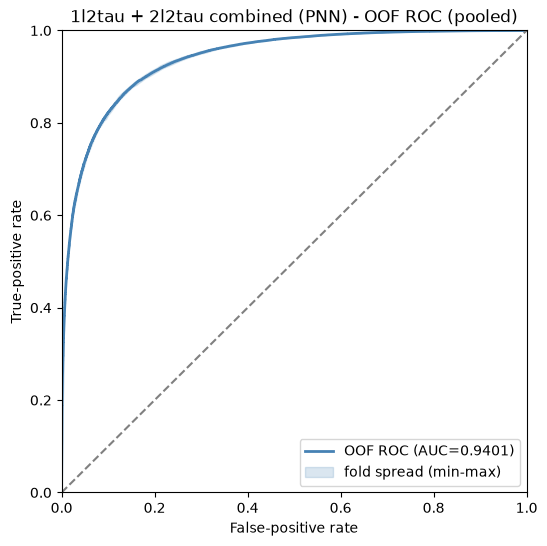

Saved 5 fold models + preprocessing + feature list + hyperparams + OOF scores -> PPSSP_2026/pnn_channel_combined/combined/ (track=combined)
Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedOOFROCPerChannel_PNN.png


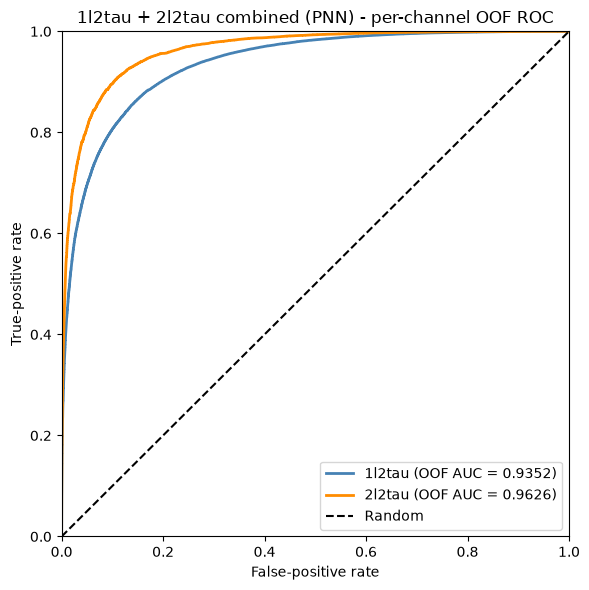


Final model: Top-15 (16 features)
Weighted AUC (POOLED): val (fold-0 preview) = 0.9347  |  OOF (5-fold, scored once per event) = 0.9401
At the fold-0-preview VAL-selected score cut = 0.9941 (frozen, NOT re-scanned on OOF):
  OOF S = 0.49 | OOF B = 11.42 | OOF Z = 0.143  (val Z was 0.164)
Per-channel OOF weighted AUC: 1l2tau=0.9352 (2015576 events) | 2l2tau=0.9626 (324510 events)
  [1l2tau] OOF S = 0.35 | OOF B = 9.21 | OOF Z = 0.114  (same frozen val cut)
  [2l2tau] OOF S = 0.14 | OOF B = 2.21 | OOF Z = 0.091  (same frozen val cut)


In [20]:
# ---- K-FOLD PRODUCTION RUN (Combined channel PNN) ---------------------------
flag_cols_final = [f for f in flag_cols if f in FINAL_MODEL_FEATURES]

oof_df, models, scalers, medians_list = run_kfold_pnn(
    data, TOP15_FEATURES, channel_cols, flag_cols_final, best_params, target_yields,
    cell_cols=("channel", "run"), n_folds=N_FOLDS, label="Combined",
)

oof_auc = plot_oof_roc(oof_df, title="1l2tau + 2l2tau combined (PNN) - OOF ROC (pooled)")

save_track_artifacts_nn(
    models, scalers, medians_list, FINAL_MODEL_FEATURES, flag_cols_final,
    best_params, oof_df, BASE_DIR_COMBINED, "combined",
)

# ---- Per-channel OOF ROC overlay -------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
for channel_name, color in [("1l2tau", "steelblue"), ("2l2tau", "darkorange")]:
    sub = oof_df[oof_df["channel"] == channel_name]
    fpr_c, tpr_c, _ = roc_curve(sub["label"], sub["score"], sample_weight=sub["w_phys"].abs())
    auc_c = roc_auc_score(sub["label"], sub["score"], sample_weight=sub["w_phys"].abs())
    ax.plot(fpr_c, tpr_c, color=color, linewidth=2, label=f"{channel_name} (OOF AUC = {auc_c:.4f})")
ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set(xlabel="False-positive rate", ylabel="True-positive rate",
       title="1l2tau + 2l2tau combined (PNN) - per-channel OOF ROC", xlim=(0, 1), ylim=(0, 1))
ax.legend(loc="lower right")
plt.tight_layout()
channel_roc_path = PLOTS_DIR_COMBINED / "ChannelCombinedOOFROCPerChannel_PNN.png"
fig.savefig(channel_roc_path, dpi=150)
print(f"Saved plot -> {channel_roc_path}")
plt.show()

# ---- Apply the fold-0-preview VAL-selected score cut (thr_val) to the OOF
# scores, FROZEN (not re-scanned) - the "blind" evaluation: every OOF score
# comes from a fold model that never trained on that row, and the cut
# itself was chosen only from the fold-0 preview's VAL partition.
auc_test = oof_auc

sel_test = oof_df["score"] >= thr_val
S_test = oof_df.loc[sel_test & (oof_df["label"] == 1), "w_phys"].sum()
B_test = oof_df.loc[sel_test & (oof_df["label"] == 0), "w_phys"].sum()
z_test = (np.sqrt(2 * ((S_test + B_test) * np.log(1 + S_test / B_test) - S_test))
          if (S_test > 0 and B_test > 0) else np.nan)

print(f"\nFinal model: {best_name}")
print(f"Weighted AUC (POOLED): val (fold-0 preview) = {final_val_auc:.4f}  |  "
      f"OOF (5-fold, scored once per event) = {auc_test:.4f}")
print(f"At the fold-0-preview VAL-selected score cut = {thr_val:.4f} (frozen, NOT re-scanned on OOF):")
print(f"  OOF S = {S_test:.2f} | OOF B = {B_test:.2f} | OOF Z = {z_test:.3f}  (val Z was {z_val:.3f})")

# Per-channel OOF AUC + Z breakdown at the same frozen cut - each event
# already carries its OWN true channel_id value in the OOF scoring (no
# fixed-hypothesis trick needed here), so this is simply the shared
# network's out-of-fold performance restricted to each channel's rows.
auc_test_1l2tau = roc_auc_score(
    oof_df.loc[oof_df["channel"] == "1l2tau", "label"],
    oof_df.loc[oof_df["channel"] == "1l2tau", "score"],
    sample_weight=oof_df.loc[oof_df["channel"] == "1l2tau", "w_phys"].abs(),
)
auc_test_2l2tau = roc_auc_score(
    oof_df.loc[oof_df["channel"] == "2l2tau", "label"],
    oof_df.loc[oof_df["channel"] == "2l2tau", "score"],
    sample_weight=oof_df.loc[oof_df["channel"] == "2l2tau", "w_phys"].abs(),
)
print(f"Per-channel OOF weighted AUC: 1l2tau={auc_test_1l2tau:.4f} "
      f"({(oof_df['channel'] == '1l2tau').sum()} events) | "
      f"2l2tau={auc_test_2l2tau:.4f} ({(oof_df['channel'] == '2l2tau').sum()} events)")

z_test_1l2tau, z_test_2l2tau = np.nan, np.nan
for cell in ("1l2tau", "2l2tau"):
    sub = oof_df[(oof_df["channel"] == cell) & sel_test]
    S_c = sub.loc[sub["label"] == 1, "w_phys"].sum()
    B_c = sub.loc[sub["label"] == 0, "w_phys"].sum()
    z_c = np.sqrt(2 * ((S_c + B_c) * np.log(1 + S_c / B_c) - S_c)) if (S_c > 0 and B_c > 0) else np.nan
    print(f"  [{cell}] OOF S = {S_c:.2f} | OOF B = {B_c:.2f} | OOF Z = {z_c:.3f}  (same frozen val cut)")
    if cell == "1l2tau":
        z_test_1l2tau = z_c
    else:
        z_test_2l2tau = z_c


## Parameterized Inference Validation

Runs against the **fold-0-preview final model** (top-15 physics features +
channel indicator, `best_name`/`FINAL_MODEL_FEATURES` from the pruning
stage above) - the same representative-preview convention used for
permutation importance/correlation pruning above; not re-run across all
`N_FOLDS` production-run models. The channel indicator column is always
present in every candidate model (see the "Correlation Pruning &
Retraining" section), so this check is meaningful regardless of which
candidate ends up final.

Two checks here, not one:

1. **Sensitivity pre-check** - does the network respond to the channel
   flag AT ALL? With only 1 of ~70 input columns devoted to it, it's a real
   risk that the network just ignores it. Fixing `channel_id` to each
   hypothesis (0 or 1) for the SAME validation batch and measuring the mean
   shift in predicted probability is a direct, necessary (not sufficient)
   test of this - if it's ~0, conditioning at the input layer isn't working
   and per-layer conditioning/FiLM should be tried next (see the model
   markdown above).
2. **Own-hypothesis check** - the standard conditional-training validation:
   for every **validation** event (fold-0 preview), `channel_id` is
   overwritten to `0` (1l2tau-mode) and `1` (2l2tau-mode), re-scoring the
   SAME trained network both times (no retraining), and each setting's
   weighted AUC is measured restricted to that channel's own events (signal
   + background). A well-behaved model should show its highest AUC for
   1l2tau events when evaluated at 1l2tau-mode, and its highest AUC for
   2l2tau events at 2l2tau-mode - i.e. the diagonal of the cross-table below
   should dominate. This is the same morphing-style check the original PNN
   literature uses, adapted from a continuous/randomized parameter to a
   real, deterministic one - there is no interpolation claim being made
   here, just "does the network actually use the channel information it was
   given".


Sensitivity check (fold-0 preview): mean |score(1l2tau-mode) - score(2l2tau-mode)| over ALL val events = 0.1573
event_subset  1l2tau events  2l2tau events
scored_at                                 
1l2tau-mode          0.9296         0.9481
2l2tau-mode          0.9167         0.9589

1l2tau events: AUC at own hypothesis = 0.9296  vs  at 2l2tau hypothesis = 0.9167
2l2tau events: AUC at own hypothesis = 0.9589  vs  at 1l2tau hypothesis = 0.9481
Channel-conditioning check PASSED: each channel scores best when the network is queried at its own hypothesis.
Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedConditioningCheck_PNN.png


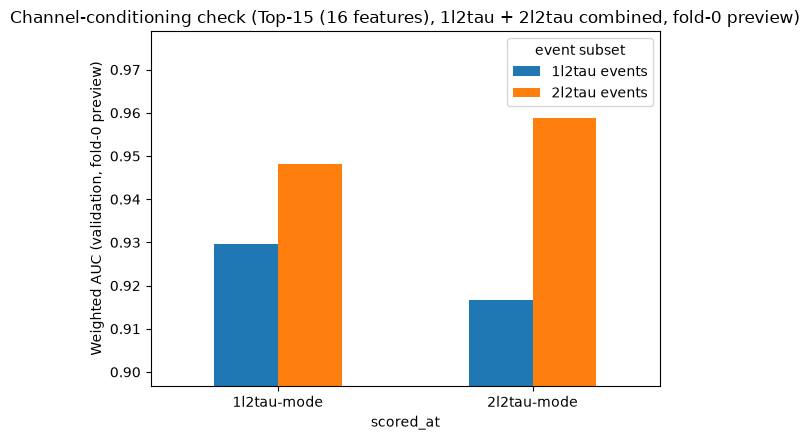

In [21]:
def score_at_fixed_channel(model, X_scaled, channel_col_idx, channel_value):

    """
    Re-score `model` on `X_scaled` (a GPU tensor already containing the
    physics + channel indicator + flag columns) after OVERWRITING the
    ordinal `channel_id` column with a single fixed value for every row -
    no retraining, just changes which channel hypothesis the shared
    network is asked to evaluate under. `channel_col_idx` = (idx_channel_id,);
    `channel_value` = (v,), e.g. (0.0,) for "1l2tau-mode".
    """

    X_fixed = X_scaled.clone()
    for idx, val in zip(channel_col_idx, channel_value):
        X_fixed[:, idx] = val
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(X_fixed)).cpu().numpy()


# Indices into FINAL_MODEL_FEATURES (the FINAL/top-15 model's own feature
# list, not the full model's MODEL_FEATURES) - the two lists put the channel
# indicator column at different positions, since pruning shrinks the physics
# feature count in front of it.
channel_col_idx = tuple(FINAL_MODEL_FEATURES.index(c) for c in channel_cols)

# ---- 1. Sensitivity pre-check: does the network respond to the flag AT ALL? ---
scores_as_1l2tau = score_at_fixed_channel(final_model, X_val_final_t, channel_col_idx, (0.0,))
scores_as_2l2tau = score_at_fixed_channel(final_model, X_val_final_t, channel_col_idx, (1.0,))
mean_abs_shift = float(np.mean(np.abs(scores_as_1l2tau - scores_as_2l2tau)))
print(f"Sensitivity check (fold-0 preview): mean |score(1l2tau-mode) - score(2l2tau-mode)| over ALL val events = {mean_abs_shift:.4f}")
if mean_abs_shift < 1e-3:
    print("  WARNING: the network barely responds to the channel flag - it may be getting ignored "
          "(consider conditioning at every hidden layer, or FiLM, instead of input-concat only).")

# ---- 2. Own-hypothesis check -----------------------------------------------
is_1l2tau_val = (fd0["val_df"]["channel"] == "1l2tau").to_numpy()
is_2l2tau_val = (fd0["val_df"]["channel"] == "2l2tau").to_numpy()

rows = []
for hypothesis_name, channel_value in [("1l2tau-mode", (0.0,)), ("2l2tau-mode", (1.0,))]:
    scores_fixed = score_at_fixed_channel(final_model, X_val_final_t, channel_col_idx, channel_value)
    for channel_name, channel_mask in [("1l2tau events", is_1l2tau_val), ("2l2tau events", is_2l2tau_val)]:
        auc = roc_auc_score(y_val[channel_mask], scores_fixed[channel_mask], sample_weight=w_val_fit[channel_mask])
        rows.append({"scored_at": hypothesis_name, "event_subset": channel_name, "weighted_auc": auc})

pnn_validation_df = pd.DataFrame(rows).pivot(index="scored_at", columns="event_subset", values="weighted_auc")
pnn_validation_df = pnn_validation_df[["1l2tau events", "2l2tau events"]]
print(pnn_validation_df.to_string(float_format=lambda x: f"{x:.4f}"))

diag_1l2tau = pnn_validation_df.loc["1l2tau-mode", "1l2tau events"]
offdiag_1l2tau = pnn_validation_df.loc["2l2tau-mode", "1l2tau events"]
diag_2l2tau = pnn_validation_df.loc["2l2tau-mode", "2l2tau events"]
offdiag_2l2tau = pnn_validation_df.loc["1l2tau-mode", "2l2tau events"]

print(f"\n1l2tau events: AUC at own hypothesis = {diag_1l2tau:.4f}  vs  at 2l2tau hypothesis = {offdiag_1l2tau:.4f}")
print(f"2l2tau events: AUC at own hypothesis = {diag_2l2tau:.4f}  vs  at 1l2tau hypothesis = {offdiag_2l2tau:.4f}")

if diag_1l2tau >= offdiag_1l2tau and diag_2l2tau >= offdiag_2l2tau:
    print("Channel-conditioning check PASSED: each channel scores best when the network is queried at its own hypothesis.")
else:
    print("Channel-conditioning check: at least one channel does NOT peak at its own hypothesis - "
          "inspect further before trusting the conditioning.")

fig, ax = plt.subplots(figsize=(6, 4.5))
pnn_validation_df.plot.bar(ax=ax, rot=0)
ax.set_ylabel("Weighted AUC (validation, fold-0 preview)")
ax.set_title(f"Channel-conditioning check ({best_name}, 1l2tau + 2l2tau combined, fold-0 preview)")
ax.set_ylim(max(0.5, pnn_validation_df.to_numpy().min() - 0.02), pnn_validation_df.to_numpy().max() + 0.02)
ax.legend(title="event subset")
plt.tight_layout()
pnn_plot_path = PLOTS_DIR_COMBINED / "ChannelCombinedConditioningCheck_PNN.png"
fig.savefig(pnn_plot_path, dpi=150)
print(f"Saved plot -> {pnn_plot_path}")
plt.show()


## Comparison Against Solo-Channel Baselines

Pooled/global numbers can be misleading here - if one channel is
intrinsically cleaner than the other, pooling raises the headline AUC even
if the combined model got WORSE in a specific channel. The only comparison
that actually matters: **for each channel, does this combined model beat
that channel's own solo-trained models (XGBoost/MLP/DNN/GNN, Combined
Run2+Run3 track) in THAT channel** - loaded from the `model_summary_*.csv`
files each of those notebooks already exports (the same files
`ModelComparison.ipynb` reads). Gracefully skips any model/channel
combination whose CSV hasn't been produced yet (that notebook not run).

**Apples-to-apples note:** each solo notebook's exported "Combined" row is
itself that notebook's own FINAL model (top-15, correlation-pruned
features, not its full baseline - see each notebook's own pruning
section), and `auc_test_1l2tau`/`auc_test_2l2tau` used below now come from
THIS notebook's final (top-15 + channel indicator) model too, so this is a
final-vs-final comparison, not full-vs-pruned.



In [22]:
SOLO_MODELS = ["xgboost", "mlp", "dnn", "gnn"]

baseline_rows = []
for channel_name in ["1l2tau", "2l2tau"]:
    for model_name in SOLO_MODELS:
        path = Path(f"PPSSP_2026/{channel_name}/summary_plots/model_summary_{model_name}.csv")
        if not path.exists():
            print(f"  (skipping {channel_name}/{model_name}: {path} not found yet)")
            continue
        baseline_df_one = pd.read_csv(path)
        combined_row = baseline_df_one[baseline_df_one["track"].astype(str).str.contains("Combined", na=False)]
        if combined_row.empty:
            print(f"  (skipping {channel_name}/{model_name}: no 'Combined' track row in {path})")
            continue
        baseline_rows.append({
            "channel": channel_name, "model": model_name,
            "test_auc": float(combined_row["test_auc"].iloc[0]),
        })

combined_channel_results = {"1l2tau": auc_test_1l2tau, "2l2tau": auc_test_2l2tau}

if baseline_rows:
    baseline_df = pd.DataFrame(baseline_rows)
    print(baseline_df.to_string(index=False))

    print("\nCombined-channel model vs. each channel's own solo baselines (test AUC):")
    for channel_name in ["1l2tau", "2l2tau"]:
        combined_auc = combined_channel_results[channel_name]
        sub = baseline_df[baseline_df["channel"] == channel_name]
        if sub.empty:
            print(f"  {channel_name}: no solo baselines found yet to compare against")
            continue
        beats_all = bool((combined_auc >= sub["test_auc"]).all())
        best_solo = sub.loc[sub["test_auc"].idxmax()]
        print(f"  {channel_name}: combined test_auc = {combined_auc:.4f}  |  "
              f"best solo baseline = {best_solo['model']} ({best_solo['test_auc']:.4f})  |  "
              f"{'BEATS all solo baselines' if beats_all else 'DOES NOT beat all solo baselines'}")
else:
    print("No solo-baseline summary CSVs found yet - run the XGBoost/MLP/DNN/GNN notebooks "
          "for the Combined Run2+Run3 track (both channels) to populate this comparison.")


  (skipping 2l2tau/gnn: PPSSP_2026/2l2tau/summary_plots/model_summary_gnn.csv not found yet)
channel   model  test_auc
 1l2tau xgboost  0.940152
 1l2tau     mlp  0.937264
 1l2tau     dnn  0.937224
 1l2tau     gnn  0.922804
 2l2tau xgboost  0.971310
 2l2tau     mlp  0.968449
 2l2tau     dnn  0.977347

Combined-channel model vs. each channel's own solo baselines (test AUC):
  1l2tau: combined test_auc = 0.9352  |  best solo baseline = xgboost (0.9402)  |  DOES NOT beat all solo baselines
  2l2tau: combined test_auc = 0.9626  |  best solo baseline = dnn (0.9773)  |  DOES NOT beat all solo baselines


Saved plot -> PPSSP_2026/pnn_channel_combined/combined/plots/ChannelCombinedVsSoloBaselines_PNN.png


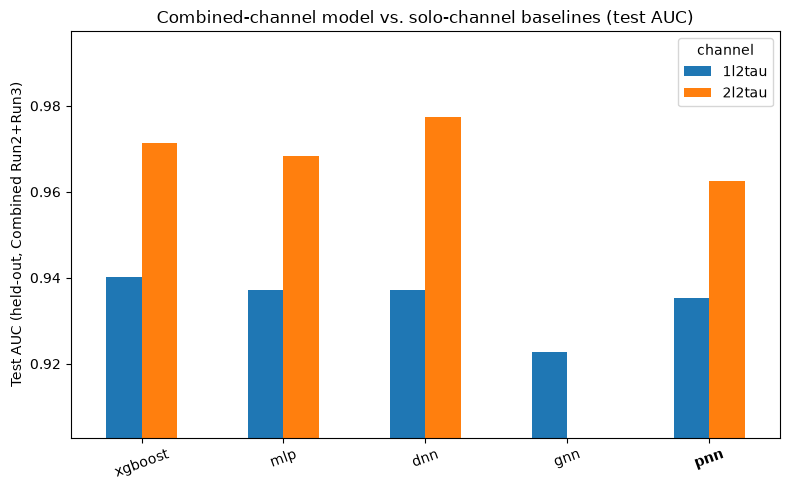

In [23]:
# Grouped bar chart: solo baselines (from `baseline_rows` above) plus this
# combined-channel model's own per-channel test AUC, side by side per model,
# grouped by channel - the visual version of the "BEATS/DOES NOT beat"
# printout above.

plot_rows = list(baseline_rows)
for channel_name, combined_auc in combined_channel_results.items():
    plot_rows.append({"channel": channel_name, "model": "pnn", "test_auc": combined_auc})

if plot_rows:
    plot_df = pd.DataFrame(plot_rows)
    pivot = plot_df.pivot(index="model", columns="channel", values="test_auc")

    model_order = [m for m in SOLO_MODELS + ["pnn"] if m in pivot.index]
    pivot = pivot.reindex(model_order)
    channel_order = [c for c in ["1l2tau", "2l2tau"] if c in pivot.columns]
    pivot = pivot[channel_order]

    fig, ax = plt.subplots(figsize=(8, 5))
    pivot.plot.bar(ax=ax, rot=20)
    ax.set_ylabel("Test AUC (held-out, Combined Run2+Run3)")
    ax.set_xlabel("")
    ax.set_title("Combined-channel model vs. solo-channel baselines (test AUC)")
    finite_vals = pivot.to_numpy()[np.isfinite(pivot.to_numpy())]
    if finite_vals.size:
        ax.set_ylim(max(0.5, finite_vals.min() - 0.02), finite_vals.max() + 0.02)
    ax.legend(title="channel")

    # Bold the "combined-channel" x-tick label so it stands out among the solo baselines.
    for label in ax.get_xticklabels():
        if label.get_text() == "pnn":
            label.set_fontweight("bold")

    plt.tight_layout()
    baseline_plot_path = PLOTS_DIR_COMBINED / "ChannelCombinedVsSoloBaselines_PNN.png"
    fig.savefig(baseline_plot_path, dpi=150)
    print(f"Saved plot -> {baseline_plot_path}")
    plt.show()
else:
    print("Nothing to plot yet - no solo-baseline CSVs found and no combined-channel results computed.")


## Sanity Checks & Final Summary

In [24]:
# ---- Sanity checks --------------------------------------------------------

assert torch.isfinite(fd0["X_train_t"]).all() and torch.isfinite(fd0["X_val_t"]).all() and torch.isfinite(fd0["X_test_t"]).all(), \
    "NaN/inf reached the model input (fold-0 preview)"

# Determinism check: re-seeding immediately before each of two short training
# runs should give an EXACT match, proving set_seed()/
# use_deterministic_algorithms(True) actually pin every source of randomness
# (weight init, dropout masks, batch shuffling). Uses a cheap config (small
# model, 5 epochs, full feature set, fold-0 preview tensors) purely to keep
# this check fast - it tests the training procedure itself, independent of
# which pruning stage/fold ends up "final".

set_seed(RANDOM_STATE)
_, _, det_check_a, _, _ = train_model(
    fd0["X_train_t"], fd0["y_train_t"], fd0["w_train_fit_t"],
    fd0["X_val_t"], fd0["y_val_t"], fd0["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)

set_seed(RANDOM_STATE)
_, _, det_check_b, _, _ = train_model(
    fd0["X_train_t"], fd0["y_train_t"], fd0["w_train_fit_t"],
    fd0["X_val_t"], fd0["y_val_t"], fd0["w_val_abs_t"],
    hidden_sizes=(64,), n_epochs=5, patience=5, verbose=False,
)

assert det_check_a == det_check_b, f"Determinism check FAILED: {det_check_a} != {det_check_b}"

print(f"Determinism check passed: two re-seeded runs give identical val_auc = {det_check_a:.6f}")

# ---- Final summary ---------------------------------------------------------
# "model" name deliberately says "conditional multi-channel" rather than
# "PNN" - see intro markdown for why that distinction matters here (no
# randomized/interpolatable parameter, channel is a real observed property
# of every event). Reports the FINAL model (best_name, top-15 physics
# features + channel conditioning) - val numbers are the fold-0-preview
# (used to pick both the model and the score cut), test numbers are the
# 5-fold OOF production run - NOT the full fold-0-preview baseline model,
# which is preserved separately under the "_full" suffix
# (val_auc_1l2tau_full/val_auc_2l2tau_full) and in the `comparison` table
# above.

summary = pd.DataFrame([{
    "model": f"Conditional multi-channel NN — {best_name} (ordinal channel_id, always retained)",
    "train_auc_eval": final_train_auc_eval,
    "val_auc (pooled, fold-0 preview)": final_val_auc,
    "val_auc_1l2tau (fold-0 preview)": val_auc_1l2tau,
    "val_auc_2l2tau (fold-0 preview)": val_auc_2l2tau,
    "max_asimov_Z (val, fold-0 preview, pooled)": z_val,
    "test_auc (pooled, OOF, 5-fold)": auc_test,
    "test_auc_1l2tau (OOF)": auc_test_1l2tau,
    "test_auc_2l2tau (OOF)": auc_test_2l2tau,
    "test_Z_at_val_cut (pooled, OOF)": z_test,
    "test_Z_1l2tau_at_val_cut (OOF)": z_test_1l2tau,
    "test_Z_2l2tau_at_val_cut (OOF)": z_test_2l2tau,
    "own_hypothesis_auc (1l2tau, 2l2tau)": (diag_1l2tau, diag_2l2tau),
    "sensitivity_mean_abs_score_shift": mean_abs_shift,
}])

print("\nFinal summary (1l2tau + 2l2tau combined) - see the `comparison` table (fold-0 preview: "
      "full/pruned/top-15) and per-channel breakdown above, and the solo-baseline comparison below, "
      "before drawing conclusions from the pooled numbers:")
print(summary.to_string(index=False))
summary


Determinism check passed: two re-seeded runs give identical val_auc = 0.916153

Final summary (1l2tau + 2l2tau combined) - see the `comparison` table (fold-0 preview: full/pruned/top-15) and per-channel breakdown above, and the solo-baseline comparison below, before drawing conclusions from the pooled numbers:
                                                                                    model  train_auc_eval  val_auc (pooled, fold-0 preview)  val_auc_1l2tau (fold-0 preview)  val_auc_2l2tau (fold-0 preview)  max_asimov_Z (val, fold-0 preview, pooled)  test_auc (pooled, OOF, 5-fold)  test_auc_1l2tau (OOF)  test_auc_2l2tau (OOF)  test_Z_at_val_cut (pooled, OOF)  test_Z_1l2tau_at_val_cut (OOF)  test_Z_2l2tau_at_val_cut (OOF)      own_hypothesis_auc (1l2tau, 2l2tau)  sensitivity_mean_abs_score_shift
Conditional multi-channel NN — Top-15 (16 features) (ordinal channel_id, always retained)        0.943331                          0.934663                         0.929647                

,model,train_auc_eval,"val_auc (pooled, fold-0 preview)",val_auc_1l2tau (fold-0 preview),val_auc_2l2tau (fold-0 preview),"max_asimov_Z (val, fold-0 preview, pooled)","test_auc (pooled, OOF, 5-fold)",test_auc_1l2tau (OOF),test_auc_2l2tau (OOF),"test_Z_at_val_cut (pooled, OOF)",test_Z_1l2tau_at_val_cut (OOF),test_Z_2l2tau_at_val_cut (OOF),"own_hypothesis_auc (1l2tau, 2l2tau)",sensitivity_mean_abs_score_shift
0,Conditional multi-channel NN — Top-15 (16 feat...,0.943331,0.934663,0.929647,0.958874,0.163705,0.940063,0.935238,0.962569,0.142607,0.114006,0.091312,"(0.9296471432135627, 0.9588744529934226)",0.157277


## Export Summary for Cross-Notebook Comparison

Written for `ModelComparison.ipynb` to load - same schema
(`channel`/`model`/`track`/`val_auc`/`test_auc`) as the XGBoost/MLP/DNN/GNN
exports. Since this single trained network covers BOTH channels, it writes
TWO rows (one per channel, each channel's own val/test AUC subset from the
per-channel breakdowns above, NOT the pooled numbers) to
`PPSSP_2026/<channel>/summary_plots/model_summary_pnn.csv` for each channel
- exactly where `ModelComparison.ipynb` already looks for a `pnn` entry per
channel, so no changes are needed there. The `model` label there stays
`"pnn"` for consistency with the other notebooks' file naming, even though
this notebook's own markdown calls it conditional multi-channel training.


In [25]:
model_summary_rows = [
    {"channel": "1l2tau", "model": "pnn", "track": "Channel-Combined (Run2+Run3)",
     "val_auc": val_auc_1l2tau, "test_auc": auc_test_1l2tau},
    {"channel": "2l2tau", "model": "pnn", "track": "Channel-Combined (Run2+Run3)",
     "val_auc": val_auc_2l2tau, "test_auc": auc_test_2l2tau},
]
model_summary_df = pd.DataFrame(model_summary_rows)

for channel_name, row_df in model_summary_df.groupby("channel"):
    out_dir = Path(f"PPSSP_2026/{channel_name}/summary_plots")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "model_summary_pnn.csv"
    row_df.to_csv(out_path, index=False)
    print(f"Saved model comparison summary -> {out_path}")

model_summary_df


Saved model comparison summary -> PPSSP_2026/1l2tau/summary_plots/model_summary_pnn.csv
Saved model comparison summary -> PPSSP_2026/2l2tau/summary_plots/model_summary_pnn.csv


,channel,model,track,val_auc,test_auc
0,1l2tau,pnn,Channel-Combined (Run2+Run3),0.929647,0.935238
1,2l2tau,pnn,Channel-Combined (Run2+Run3),0.958874,0.962569
